# Week-19

ecosystem_palette = {
    "Lakes": "#56B4E9",
    "Streams": "#009E73",
    "Marine": "#0072B2",
    "Terrestrial aboveground": "#4DAF4A",
    "Terrestrial belowground": "#A6761D",
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#bab6f2",
    "Directed": "#6edeed",
    "Directed-Negative": "#1f78b4",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

In [6]:
import pandas as pd
import numpy as np

path = "../../../src/matlab/data/result/statistical_tests/wlnm_dir_neg_delta_ttests.csv"
df = pd.read_csv(path)

df["Cohen_dz"] = df["MeanDelta"] / df["StdDelta"]
df["MinusLog10P"] = -np.log10(df["PValue"])
df["Direction"] = np.where(df["MeanDelta"] >= 0, "Generated > empirical", "Generated < empirical")

print(df[[
    "Metric", "NumFoodWebs", "MeanDelta", "StdDelta",
    "TStatistic", "DF", "PValue", "RejectH0", "Cohen_dz", "Direction"
]].sort_values("PValue"))


              Metric  NumFoodWebs  MeanDelta    StdDelta  TStatistic  DF  \
1        Connectance            3  -0.022516    0.019891   -1.960633   2   
3         MeanDegree            3  -1.871327    2.415700   -1.341737   2   
4     MeanGenerality            3  -1.600283    2.155513   -1.285899   2   
0              Links            3 -66.333333  104.500399   -1.099448   2   
6          PropBasal            3  -0.051282    0.088823   -1.000000   2   
7   PropIntermediate            3  -0.051282    0.088823   -1.000000   2   
8            PropTop            3   0.025641    0.044412    1.000000   2   
5  MeanVulnerability            3  -0.769459    1.498546   -0.889357   2   
2   MeanTrophicLevel            3  -0.046757    0.093583   -0.865392   2   

     PValue  RejectH0  Cohen_dz              Direction  
1  0.188968         0 -1.131972  Generated < empirical  
3  0.311727         0 -0.774652  Generated < empirical  
4  0.327256         0 -0.742414  Generated < empirical  
0  0.386232

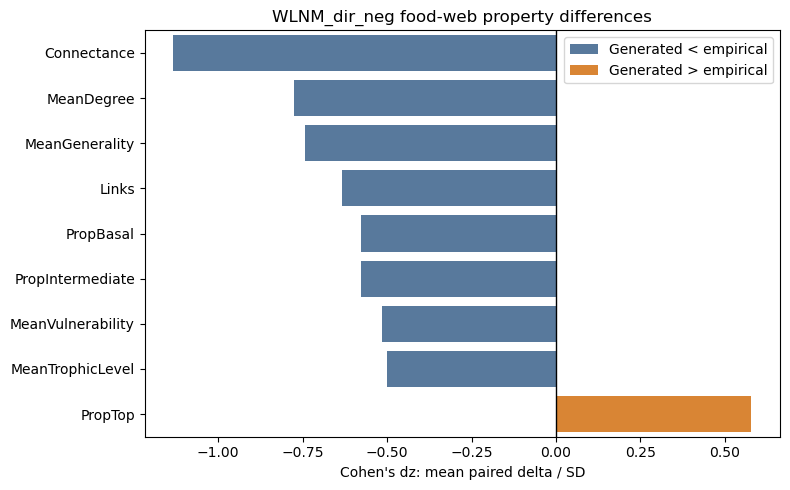

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.sort_values("Cohen_dz")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    y="Metric",
    x="Cohen_dz",
    hue="Direction",
    dodge=False,
    palette={
        "Generated < empirical": "#4C78A8",
        "Generated > empirical": "#F58518",
    }
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Cohen's dz: mean paired delta / SD")
plt.ylabel("")
plt.title("WLNM_dir_neg food-web property differences")
plt.legend(title="")
plt.tight_layout()
plt.show()


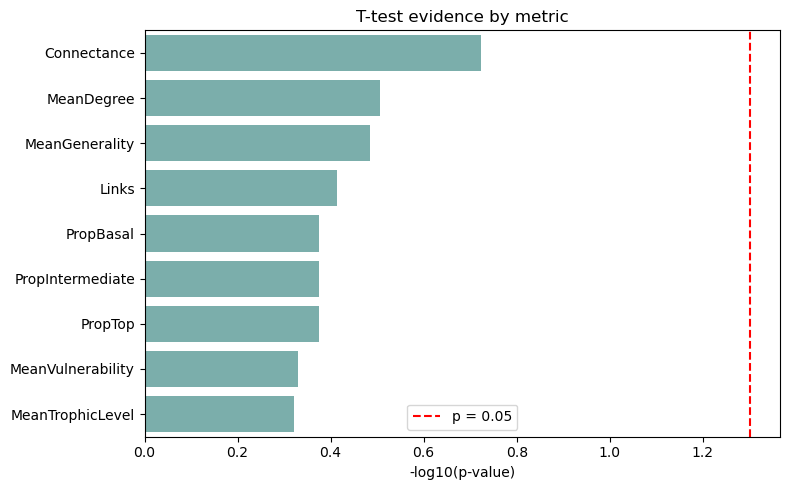

In [8]:
plot_df = df.sort_values("PValue")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, y="Metric", x="MinusLog10P", color="#72B7B2")
plt.axvline(-np.log10(0.05), color="red", linestyle="--", label="p = 0.05")
plt.xlabel("-log10(p-value)")
plt.ylabel("")
plt.title("T-test evidence by metric")
plt.legend()
plt.tight_layout()
plt.show()


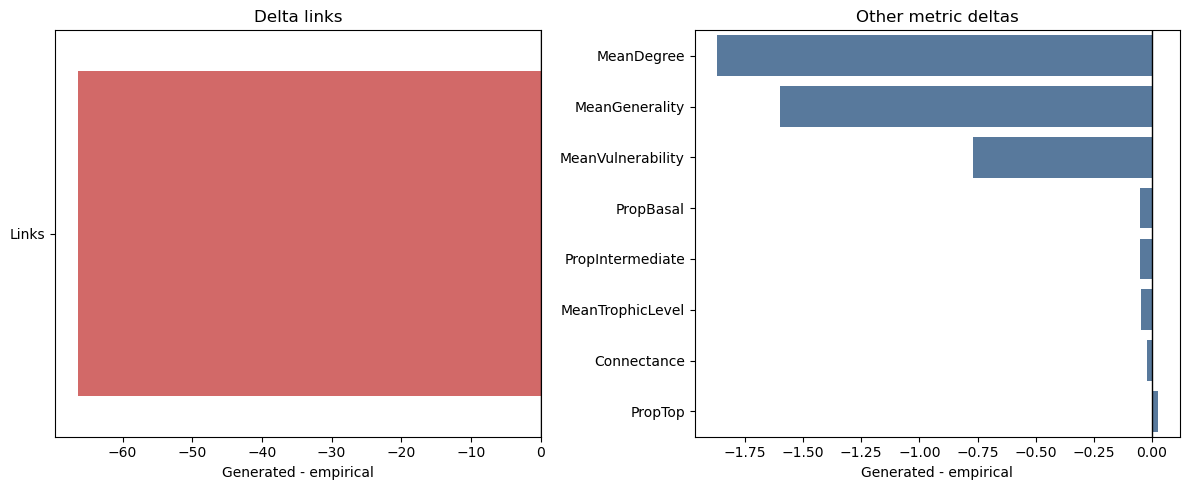

In [9]:
links = df[df["Metric"].eq("Links")]
others = df[~df["Metric"].eq("Links")].sort_values("MeanDelta")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=links, y="Metric", x="MeanDelta", color="#E45756", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Delta links")
axes[0].set_xlabel("Generated - empirical")

sns.barplot(data=others, y="Metric", x="MeanDelta", color="#4C78A8", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Other metric deltas")
axes[1].set_xlabel("Generated - empirical")

for ax in axes:
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


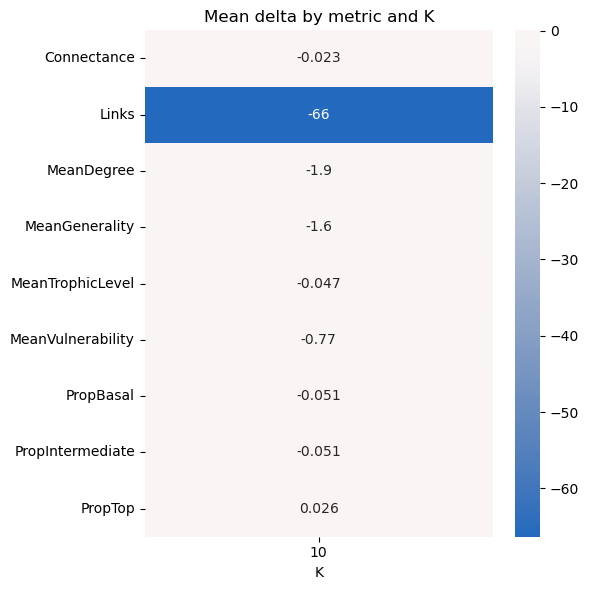

In [10]:
heat = df.pivot_table(
    index="Metric",
    columns="K",
    values="MeanDelta",
    aggfunc="mean"
)

plt.figure(figsize=(6, 6))
sns.heatmap(heat, annot=True, cmap="vlag", center=0)
plt.title("Mean delta by metric and K")
plt.xlabel("K")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

result_dir = Path("../../../src/matlab/data/result/prediction_scores_logs")

files = list(result_dir.glob("*_results_random_wlnm_dir_neg.csv"))

rows = []
for file in files:
    df = pd.read_csv(file)
    df["FoodWeb"] = file.name.replace("_tax_mass_results_random_wlnm_dir_neg.csv", "")
    rows.append(df)

raw = pd.concat(rows, ignore_index=True)

delta_cols = [
    "DeltaLinks",
    "DeltaConnectance",
    "DeltaMeanTrophicLevel",
    "DeltaMeanDegree",
    "DeltaMeanGenerality",
    "DeltaMeanVulnerability",
    "DeltaPropBasal",
    "DeltaPropIntermediate",
    "DeltaPropTop",
]

long = raw.melt(
    id_vars=["FoodWeb", "K", "TrainRatio", "ThresholdMode"],
    value_vars=delta_cols,
    var_name="Metric",
    value_name="Delta"
)

long["Metric"] = long["Metric"].str.replace("Delta", "", regex=False)


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_42536/3263702154.py:20: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


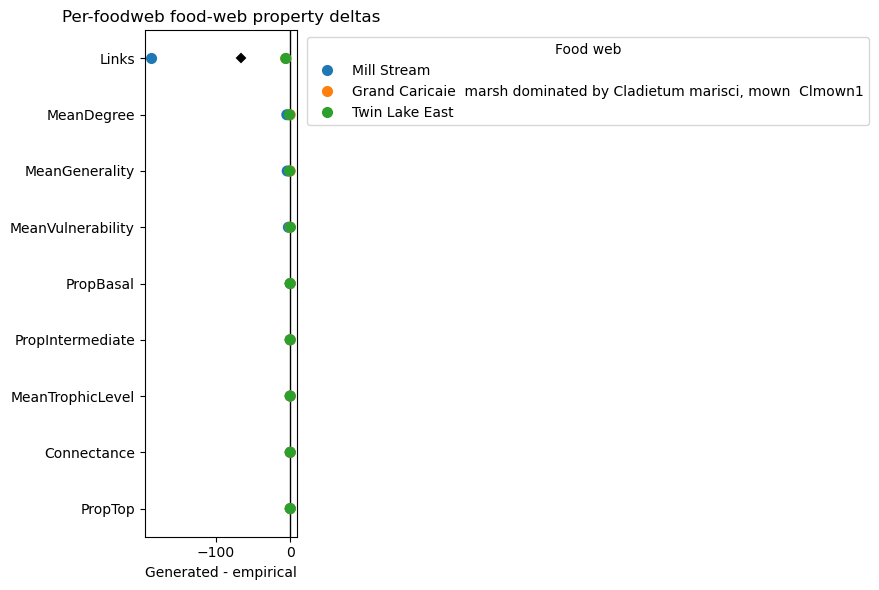

In [12]:
plt.figure(figsize=(9, 6))

order = (
    long.groupby("Metric")["Delta"]
    .mean()
    .sort_values()
    .index
)

sns.stripplot(
    data=long,
    y="Metric",
    x="Delta",
    order=order,
    hue="FoodWeb",
    size=8,
    jitter=False
)

sns.pointplot(
    data=long,
    y="Metric",
    x="Delta",
    order=order,
    errorbar=None,
    color="black",
    markers="D",
    linestyles="none",
    scale=0.7
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Generated - empirical")
plt.ylabel("")
plt.title("Per-foodweb food-web property deltas")
plt.legend(title="Food web", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


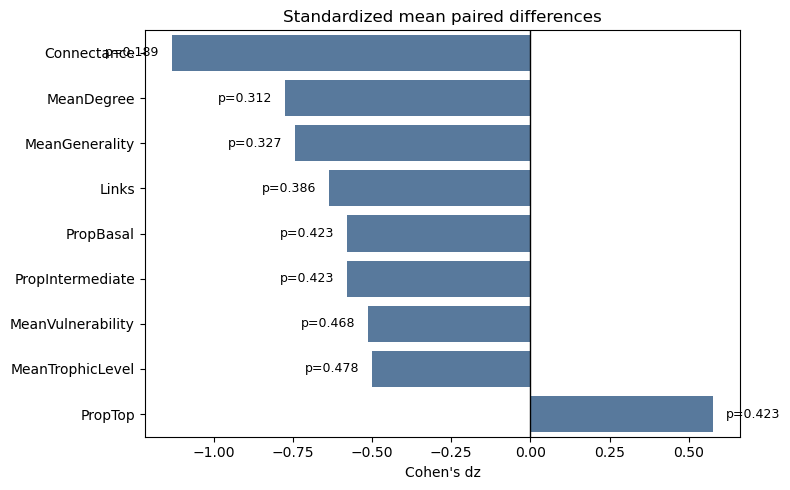

In [13]:
summary = pd.read_csv(
    "../../../src/matlab/data/result/statistical_tests/wlnm_dir_neg_delta_ttests.csv"
)

summary["Cohen_dz"] = summary["MeanDelta"] / summary["StdDelta"]
summary = summary.sort_values("Cohen_dz")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=summary,
    y="Metric",
    x="Cohen_dz",
    color="#4C78A8"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Cohen's dz")
plt.ylabel("")
plt.title("Standardized mean paired differences")

for i, row in enumerate(summary.itertuples()):
    x = row.Cohen_dz
    label_x = x - 0.04 if x < 0 else x + 0.04
    ha = "right" if x < 0 else "left"
    ax.text(label_x, i, f"p={row.PValue:.3f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()


[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Applied TrainRatio filter: TrainRatio == 90


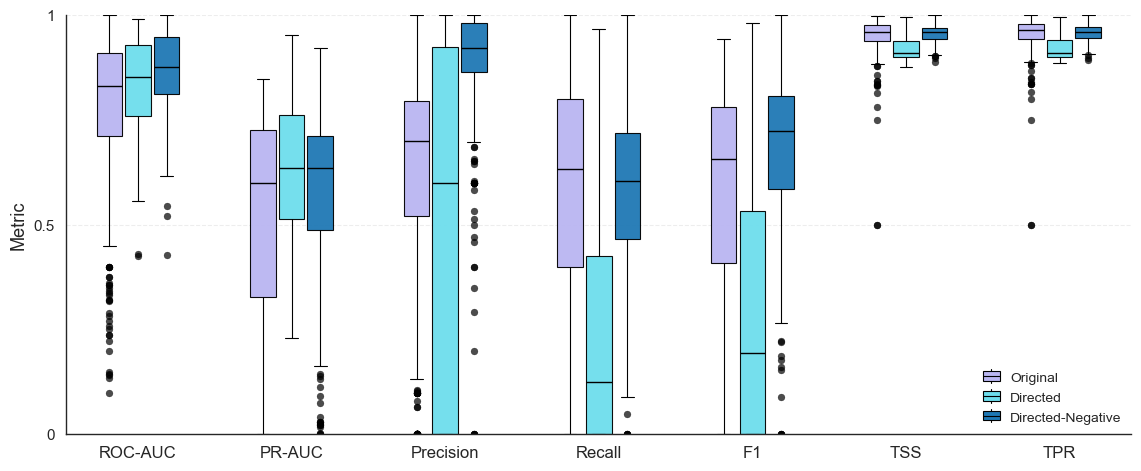

In [ ]:
import os
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
RESULTS_DIR_DIRECTED = Path("../../../src/matlab/data/result_wlnm_directed_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]
K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    # Filter only TrainRatio = 60
    if TRAIN_RATIO_TARGET is not None:
        if TRAIN_RATIO_COL not in df.columns:
            print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
            return None

        df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

        if df.empty:
            return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    valid_any = False
    for metric in METRICS:
        if metric in df.columns:
            vals = df[metric].dropna().values
            out[f"{metric}_mean"] = float(np.mean(vals)) if vals.size else np.nan
            if vals.size:
                valid_any = True
        else:
            out[f"{metric}_mean"] = np.nan

    if not valid_any:
        return None

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, version=version)
        if rec is not None:
            rows.append(rec)

    return rows


# =========================
# Load all CSVs (four folders)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIRECTED, GLOB_PATTERN_DIRECTED, version="directed")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check patterns or CSV columns.")


# =========================
# Apply NODE_THRESHOLD logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", nodes_col]].copy()
allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")
print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")


# =========================
# Optional: enforce one row per Foodweb per Version
# =========================
mean_cols = [f"{metric}_mean" for metric in METRICS]
df_all = (
    df_all
    .groupby(["Foodweb", "Version"], as_index=False)[mean_cols]
    .mean()
)

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        # Slight downward shift for visual alignment with text
        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        # Smaller box so whiskers sit clearly outside
        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        # Whisker ends must stay outside the box
        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# =========================
# Plot: single-panel boxplots comparing versions across metrics
# =========================
order = ["original", "directed", "dir_neg"]
label_map = {
    "original": "Original",
    "directed": "Directed",
    "dir_neg": "Directed-Negative",
}

palette = {
    "original": "#bab6f2",
    "directed": "#6edeed",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC_mean", "ROC-AUC"),
    ("PR_AUC_mean", "PR-AUC"),
    ("Precision_mean", "Precision"),
    ("Recall_mean", "Recall"),
    ("F1Score_mean", "F1"),
    ("PseudoTSS_mean", "TSS"),
    ("PseudoTPR_mean", "TPR"),
]

fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

# Small offsets so versions within the same metric stay close together
offsets = np.array([-0.28, 0.0, 0.28])
box_width = 0.25

legend_handles = []

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    bp = ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels([label for _, label in plot_metrics], rotation=0, ha="center", fontsize=12)

ax.set_ylabel("Metric", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Filtered results by TrainRatio: kept only TrainRatio = 60.
Filtered food webs by size: kept 160 / 290 (>= 40 nodes).


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_51264/1284904198.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_51264/1284904198.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_51264/1284904198.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_51264/1284904198.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

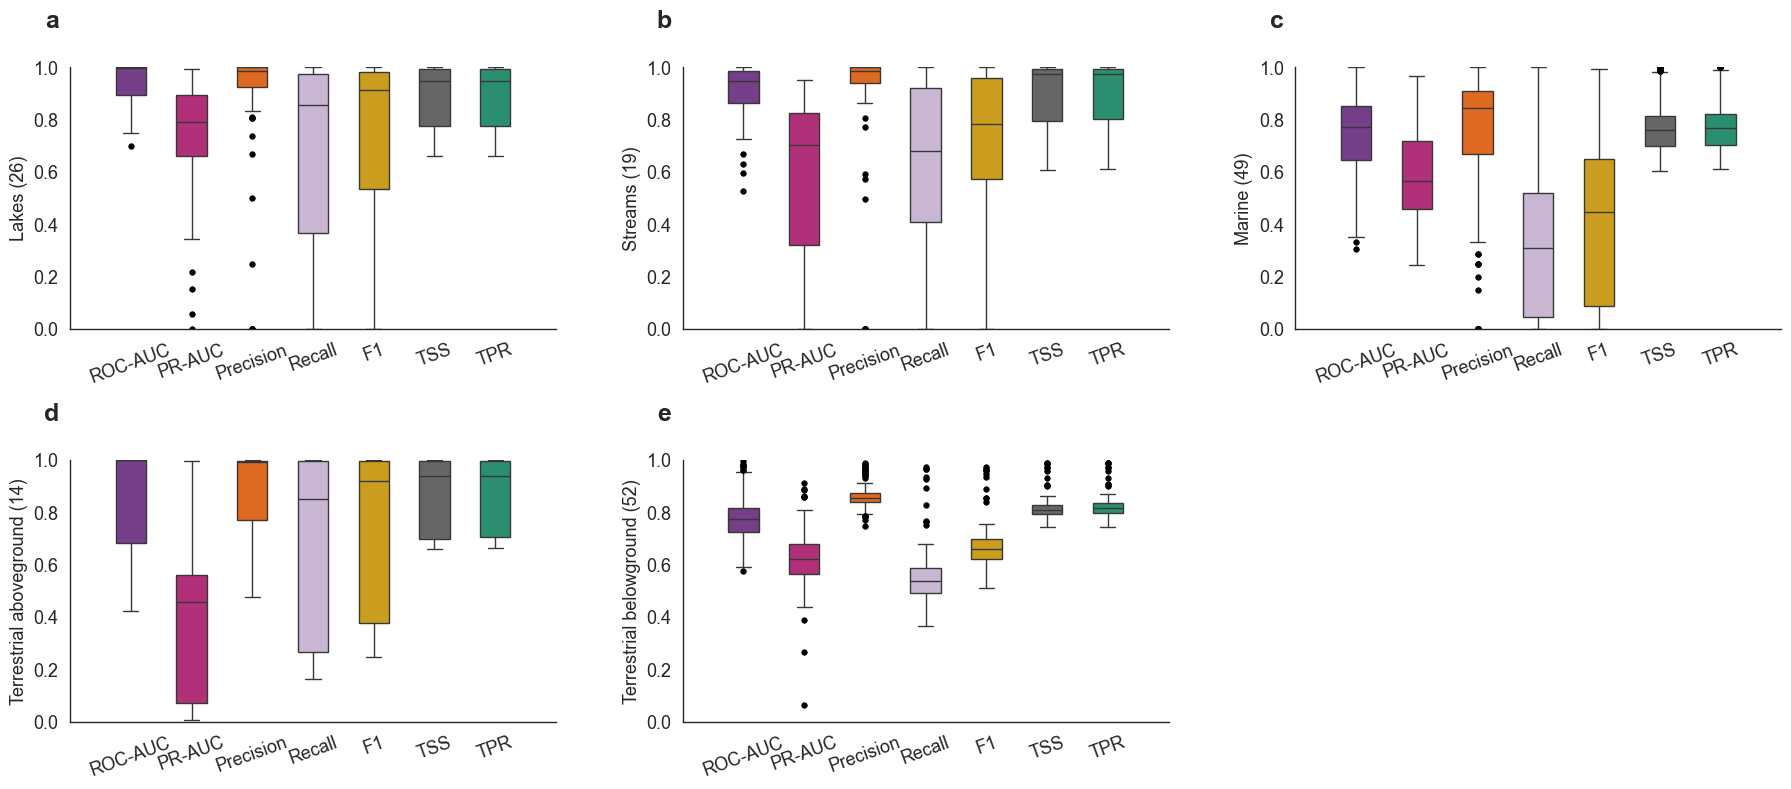

In [20]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]
xtick_labels = ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1", "TSS", "TPR"]
MIN_NODES = 40
TRAIN_RATIO_TARGET = 60
TRAIN_RATIO_COL = "TrainRatio"
Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",    # purple
    "PR_AUC": "#C51B7D",     # magenta
    "Precision": "#FE6100",  # orange
    "Recall": "#CAB2D6",     # violet
    "F1Score": "#E6AB02",    # mustard
    "PseudoTSS": "#666666",  # dark gray
    "PseudoTPR": "#1B9E77",  # teal-green
}

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Filter TrainRatio = 60 before merging/melting ===
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

print(f"Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
labels_map = {eco: f"{str(eco).strip().capitalize()} ({n})" for eco, n in labels_map.items()}

# === Data already filtered to TrainRatio = 60 ===
subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: fit panels into two rows ===
n_panels = len(ecosystem_order)
n_rows = 2
n_cols = math.ceil(n_panels / n_rows)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 8),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, eco in enumerate(ecosystem_order):
    ax = axes[i]
    sub = subset[subset["EcosystemType"] == eco].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="Metric",
        y="Value",
        order=METRIC_ORDER,
        palette=metric_palette,
        # hue="Metric",
        legend=False,
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(METRIC_ORDER)))
    ax.set_xticklabels(xtick_labels, rotation=20, fontsize=13)

    ax.set_ylabel(labels_map.get(eco, eco), fontsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xlim(-1, len(METRIC_ORDER) - 1 + 1)

    ax.set_ylim(0, 1.0)
    # ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

    # ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=5)
plt.show()

Filtered results by TrainRatio: kept only TrainRatio = 90.
Filtered food webs by size: kept 290 / 290 (>= 0 nodes).


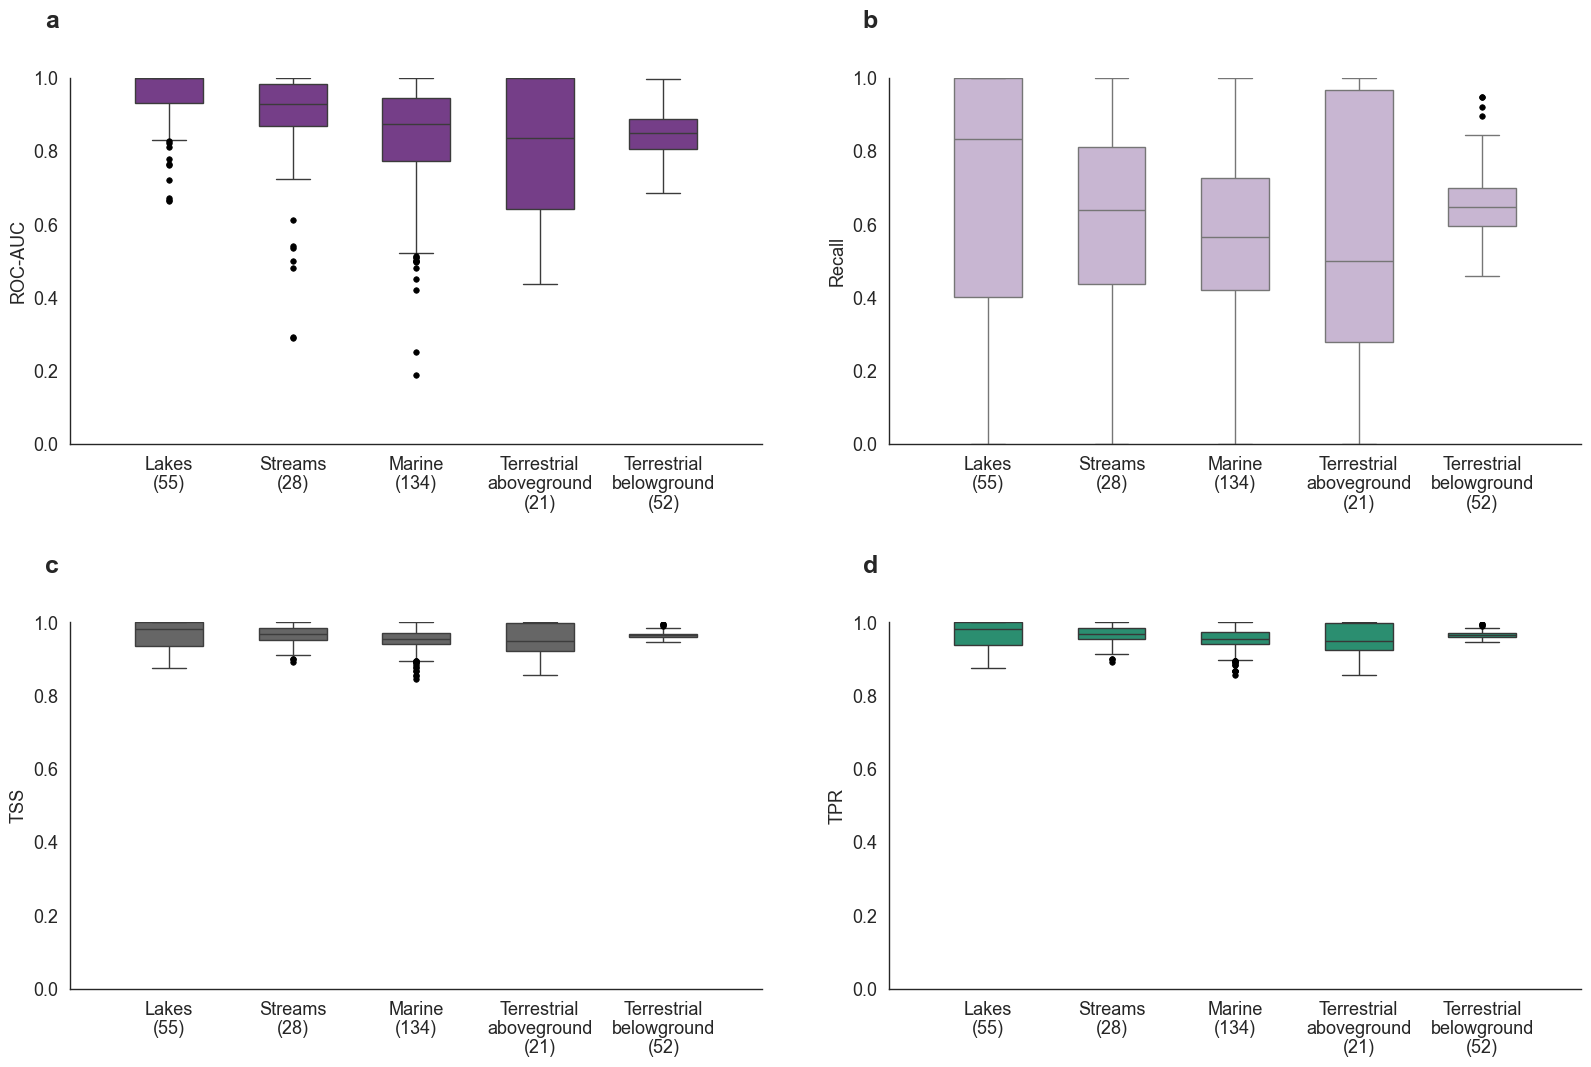

In [1]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "Recall", "PseudoTSS", "PseudoTPR"]
xtick_labels = ["ROC-AUC", "Recall", "TSS", "TPR"]
MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"
Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",    # purple
    "PR_AUC": "#C51B7D",     # magenta
    "Precision": "#FE6100",  # orange
    "Recall": "#CAB2D6",     # violet
    "F1Score": "#E6AB02",    # mustard
    "PseudoTSS": "#666666",  # dark gray
    "PseudoTPR": "#1B9E77",  # teal-green
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "Recall": "Recall",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Filter TrainRatio = 60 before merging/melting ===
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

print(f"Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    label = label_replacements.get(eco_lower, eco_clean.capitalize())
    return f"{label}\n({n})"

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

# === Data already filtered to TrainRatio = 60 ===
subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: metric panels, with ecosystems placed next to each other ===
n_panels = len(METRIC_ORDER)
n_rows = 2
n_cols = math.ceil(n_panels / n_rows)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16, 11),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        legend=False,
        width=0.55,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)

    ax.set_ylim(0, 1.0)
    # ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

    # ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0.02, 1, 1], w_pad=5, h_pad=3)
plt.show()


[INFO] Filtered results by TrainRatio: kept only 90.


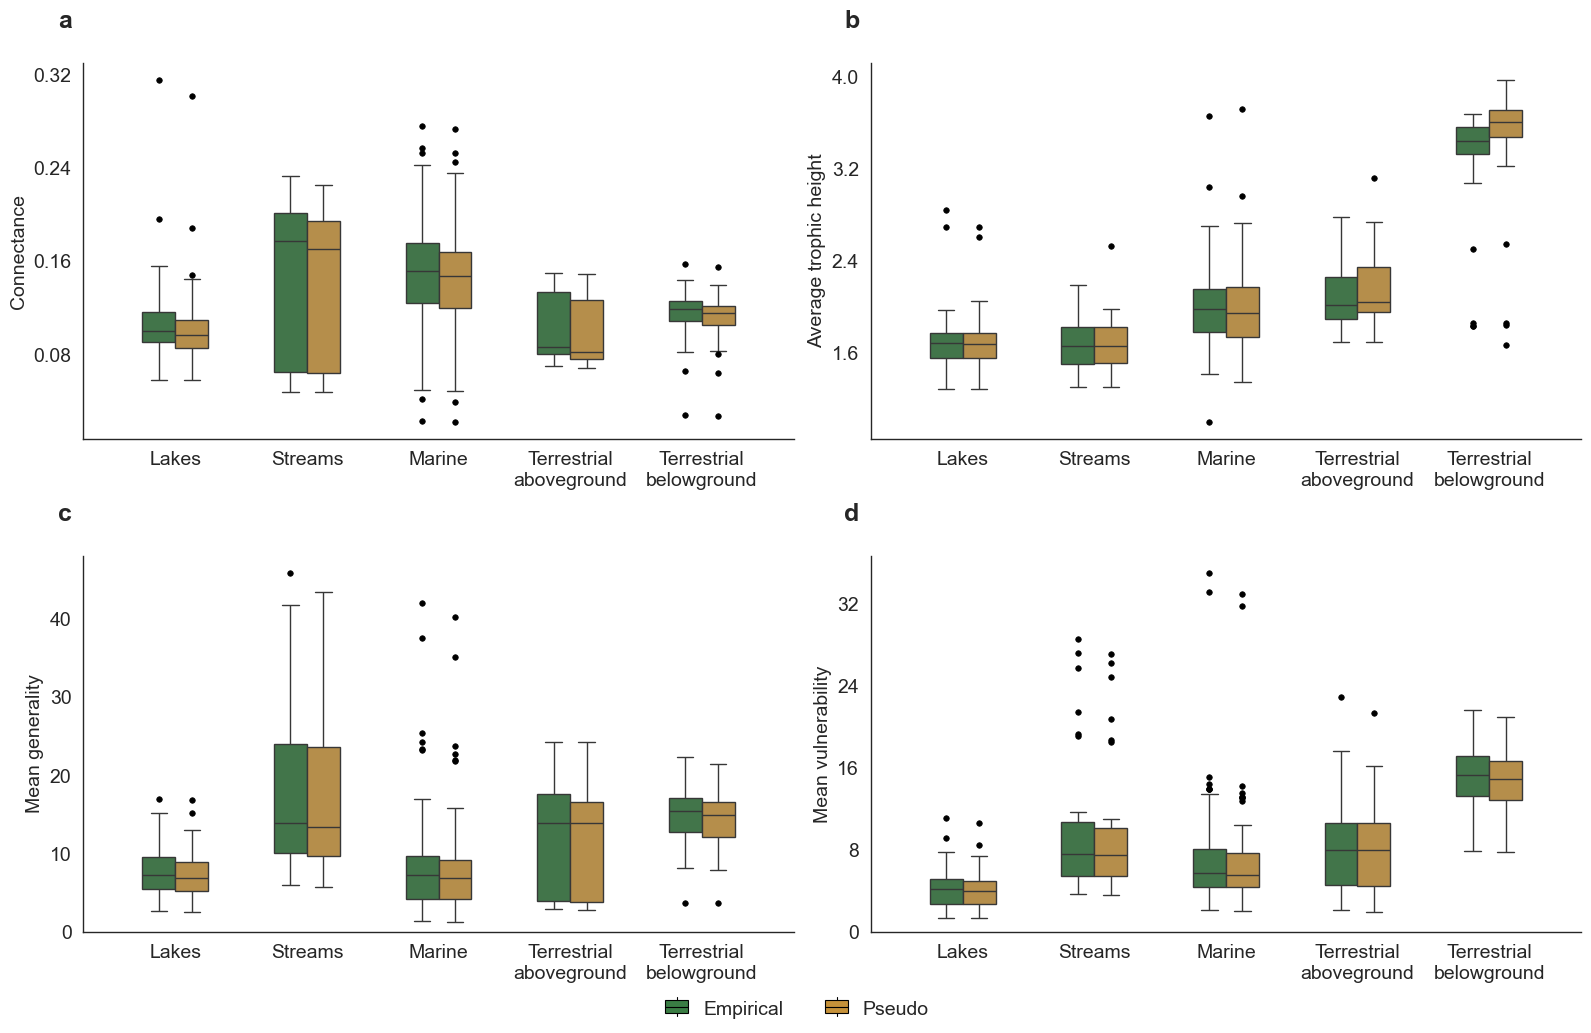

In [5]:
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white")

# ============================================================
# CONFIG
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

NODES_THRESHOLD = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"
AGGREGATE_PER_FOODWEB = True
TROPHIC_LEVEL_MIN = 1.0
TROPHIC_LEVEL_MAX = 4.0
LINKS_Q_LOW = 0.00
LINKS_Q_HIGH = 0.98

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

paired_specs = [
    ("EmpiricalConnectance",       "PseudoConnectance",       "Connectance"),
    ("EmpiricalMeanTrophicLevel",  "PseudoMeanTrophicLevel",  "Average trophic height"),
    ("EmpiricalMeanGenerality",    "PseudoMeanGenerality",    "Mean generality"),
    ("EmpiricalMeanVulnerability", "PseudoMeanVulnerability", "Mean vulnerability"),
]

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

type_offset = {
    "Empirical": -0.41,
    "Pseudo": 0.41,
}

# ============================================================
# HELPERS
# ============================================================
def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def find_col(df: pd.DataFrame, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name = Path(name).stem
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)

def load_all_results(results_dir: Path) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / "*_results_*.csv")))
    if not files:
        raise FileNotFoundError(f"No results CSVs found in: {results_dir}")

    dfs = []
    for fp in files:
        try:
            df = pd.read_csv(fp)
            df["Foodweb"] = extract_foodweb_name(fp)
            dfs.append(df)
        except Exception as e:
            print(f"[WARN] Skipping {fp}: {e}")

    if not dfs:
        raise RuntimeError("No readable result CSVs were loaded.")

    return pd.concat(dfs, ignore_index=True)

def load_ecosystem_metadata(ecosystem_csv: Path) -> pd.DataFrame:
    meta = pd.read_csv(ecosystem_csv)

    foodweb_col = find_col(meta, ["Foodweb", "foodweb"])
    eco_col = find_col(meta, ["Ecosystem", "ecosystem", "EcosystemType", "ecosystem_type"])
    nodes_col = find_col(meta, ["Nodes", "nodes"])

    meta = meta.rename(columns={
        foodweb_col: "Foodweb",
        eco_col: "Ecosystem",
        nodes_col: "Nodes"
    })

    meta["Foodweb"] = meta["Foodweb"].astype(str)
    meta["Ecosystem"] = meta["Ecosystem"].astype(str)
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["FW_KEY"] = meta["Foodweb"].apply(normalize_fw_label)

    return meta[["Foodweb", "Ecosystem", "Nodes", "FW_KEY"]].drop_duplicates()

def safe_numeric_filter(df: pd.DataFrame) -> pd.DataFrame:
    for c in ["K", TRAIN_RATIO_COL]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df = df[pd.notna(df[c])]
    return df

def aggregate_foodweb_runs(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    grouped = df.groupby("Foodweb", as_index=False)[numeric_cols].mean()

    eco_map = df[["Foodweb", "Ecosystem"]].drop_duplicates()
    grouped = grouped.merge(eco_map, on="Foodweb", how="left")

    cols = ["Foodweb", "Ecosystem"] + [c for c in grouped.columns if c not in ("Foodweb", "Ecosystem")]
    return grouped[cols]

# ============================================================
# LOAD + PREPARE DATA
# ============================================================
results = load_all_results(RESULTS_DIR)
meta = load_ecosystem_metadata(ECOSYSTEM_CSV)

results = safe_numeric_filter(results)

# === Filter TrainRatio = 60 before node filtering, merging, and aggregation ===
if TRAIN_RATIO_COL not in results.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

results = results[results[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if results.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check whether TrainRatio is stored as 60, 60.0, or another scale such as 0.6."
    )

print(f"[INFO] Filtered results by {TRAIN_RATIO_COL}: kept only {TRAIN_RATIO_TARGET}.")

results["FW_KEY"] = results["Foodweb"].apply(normalize_fw_label)

allowed_fw_keys = set(meta.loc[meta["Nodes"] >= NODES_THRESHOLD, "FW_KEY"].dropna().unique())
results = results[results["FW_KEY"].isin(allowed_fw_keys)].copy()

if results.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

required_plot_cols = sorted(
    {"Ecosystem"} | {c for spec in paired_specs for c in spec[:2]}
)
existing_required = [c for c in required_plot_cols if c in results.columns]
results = results.dropna(subset=existing_required)

results = results.merge(
    meta[["FW_KEY", "Ecosystem"]].drop_duplicates(),
    on="FW_KEY",
    how="left",
    suffixes=("", "_meta")
)

if "Ecosystem_meta" in results.columns:
    results["Ecosystem"] = results["Ecosystem"].fillna(results["Ecosystem_meta"])
    results = results.drop(columns=["Ecosystem_meta"])

plot_df = aggregate_foodweb_runs(results) if AGGREGATE_PER_FOODWEB else results.copy()

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# ============================================================
# PLOT
# ============================================================
n_panels = len(paired_specs)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

for idx, (ax, (emp_col, pseudo_col, title)) in enumerate(zip(axes, paired_specs)):
    panel_df = plot_df.dropna(subset=[emp_col, pseudo_col, "Ecosystem"]).copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    # Keep the trophic-level filter if needed
    if title == "Average trophic height":
        panel_df = panel_df[
            np.isfinite(panel_df[emp_col]) &
            np.isfinite(panel_df[pseudo_col]) &
            panel_df[emp_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX) &
            panel_df[pseudo_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX)
        ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    eco_order = present_ecosystems + extra_ecosystems

    long_df = panel_df.melt(
        id_vars=["Ecosystem"],
        value_vars=[emp_col, pseudo_col],
        var_name="NetworkType",
        value_name="Value",
    )

    long_df["NetworkType"] = long_df["NetworkType"].map({
        emp_col: "Empirical",
        pseudo_col: "Pseudo",
    })

    sns.boxplot(
        data=long_df,
        x="Ecosystem",
        y="Value",
        hue="NetworkType",
        order=eco_order,
        hue_order=["Empirical", "Pseudo"],
        palette=type_palette,
        ax=ax,
        width=0.5,
        dodge=True,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_title("")
    ax.set_ylabel(title, fontsize=14)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    ax.set_xlim(-0.7, len(eco_order) - 1 + 0.7)

    # Independent y-axis zoom per panel
    panel_vals = long_df["Value"].dropna().values
    if panel_vals.size:
        local_min = np.nanmin(panel_vals)
        local_max = np.nanmax(panel_vals)
        pad = 0.05 * (local_max - local_min) if local_max > local_min else 0.05

        # Only force non-negative lower bound; do NOT cap upper bound at 1.0
        local_min = max(0.0, local_min - pad)
        local_max = local_max + pad

        if np.isclose(local_min, local_max):
            local_min = max(0.0, local_min - 0.02)
            local_max = local_max + 0.02

        ax.set_ylim(local_min, local_max)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    ax.set_xticks(range(len(eco_order)))
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(paired_specs), len(axes)):
    axes[j].set_visible(False)

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.5, 0.01),
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout()
plt.show()

[INFO] Filtered results by TrainRatio: kept only 90.

[INFO] Paired t-test results by metric and ecosystem:
                Metric               Ecosystem  NumFoodWebs  MeanEmpirical  MeanPseudo  MeanDelta  StdDelta  TStatistic  DF       PValue  RejectH0
           Connectance                   lakes           53       0.106468    0.102831  -0.003637  0.003862   -6.857194  52 8.360606e-09      True
           Connectance                 streams           28       0.148668    0.143000  -0.005668  0.004900   -6.120990  27 1.539042e-06      True
           Connectance                  marine          134       0.151340    0.145938  -0.005403  0.003430  -18.231045 133 5.476313e-38      True
           Connectance terrestrial aboveground           21       0.102924    0.099416  -0.003508  0.003173   -5.065894  20 5.908091e-05      True
           Connectance terrestrial belowground           52       0.115029    0.111639  -0.003390  0.001008  -24.262598  51 1.133598e-29      True
Average tr

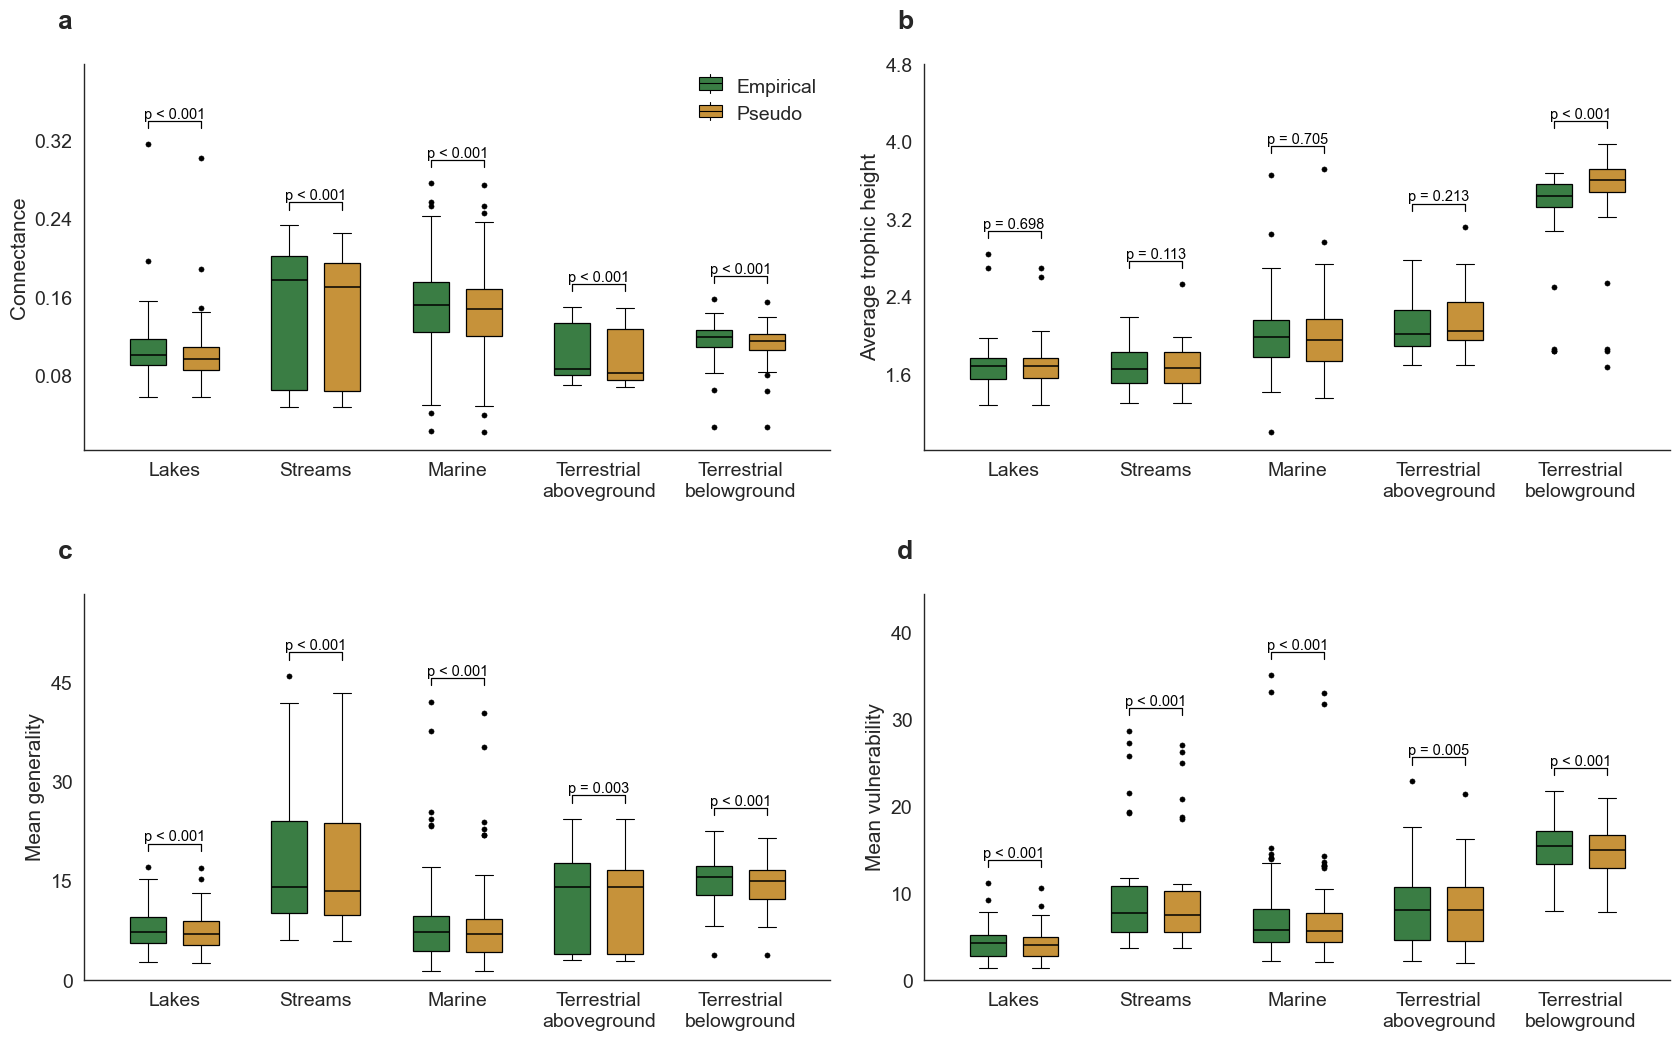

In [ ]:
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# CONFIG
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

NODES_THRESHOLD = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"
AGGREGATE_PER_FOODWEB = True
TROPHIC_LEVEL_MIN = 1.0
TROPHIC_LEVEL_MAX = 4.0
LINKS_Q_LOW = 0.00
LINKS_Q_HIGH = 0.98

# Bigger boxes, but separated enough inside each ecosystem group
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

paired_specs = [
    ("EmpiricalConnectance",       "PseudoConnectance",       "Connectance"),
    ("EmpiricalMeanTrophicLevel",  "PseudoMeanTrophicLevel",  "Average trophic height"),
    ("EmpiricalMeanGenerality",    "PseudoMeanGenerality",    "Mean generality"),
    ("EmpiricalMeanVulnerability", "PseudoMeanVulnerability", "Mean vulnerability"),
]

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def find_col(df: pd.DataFrame, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name = Path(name).stem
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)

def load_all_results(results_dir: Path) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / "*_results_*.csv")))
    if not files:
        raise FileNotFoundError(f"No results CSVs found in: {results_dir}")

    dfs = []
    for fp in files:
        try:
            df = pd.read_csv(fp)
            df["Foodweb"] = extract_foodweb_name(fp)
            dfs.append(df)
        except Exception as e:
            print(f"[WARN] Skipping {fp}: {e}")

    if not dfs:
        raise RuntimeError("No readable result CSVs were loaded.")

    return pd.concat(dfs, ignore_index=True)

def load_ecosystem_metadata(ecosystem_csv: Path) -> pd.DataFrame:
    meta = pd.read_csv(ecosystem_csv)

    foodweb_col = find_col(meta, ["Foodweb", "foodweb"])
    eco_col = find_col(meta, ["Ecosystem", "ecosystem", "EcosystemType", "ecosystem_type"])
    nodes_col = find_col(meta, ["Nodes", "nodes"])

    meta = meta.rename(columns={
        foodweb_col: "Foodweb",
        eco_col: "Ecosystem",
        nodes_col: "Nodes"
    })

    meta["Foodweb"] = meta["Foodweb"].astype(str)
    meta["Ecosystem"] = meta["Ecosystem"].astype(str).str.strip().str.lower()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["FW_KEY"] = meta["Foodweb"].apply(normalize_fw_label)

    return meta[["Foodweb", "Ecosystem", "Nodes", "FW_KEY"]].drop_duplicates()

def safe_numeric_filter(df: pd.DataFrame) -> pd.DataFrame:
    for c in ["K", TRAIN_RATIO_COL]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df = df[pd.notna(df[c])]
    return df

def aggregate_foodweb_runs(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    grouped = df.groupby("Foodweb", as_index=False)[numeric_cols].mean()

    eco_map = df[["Foodweb", "Ecosystem"]].drop_duplicates()
    grouped = grouped.merge(eco_map, on="Foodweb", how="left")

    cols = ["Foodweb", "Ecosystem"] + [c for c in grouped.columns if c not in ("Foodweb", "Ecosystem")]
    return grouped[cols]

def student_t_two_tailed_p(t_stat, df):
    try:
        from scipy.stats import t
        return 2.0 * t.sf(abs(t_stat), df)
    except Exception:
        # Fallback: normal approximation if scipy is unavailable.
        import math
        return math.erfc(abs(t_stat) / math.sqrt(2.0))

def paired_delta_ttest(values_a, values_b):
    a = pd.to_numeric(pd.Series(values_a), errors="coerce").to_numpy()
    b = pd.to_numeric(pd.Series(values_b), errors="coerce").to_numpy()

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    delta = b - a
    delta = delta[np.isfinite(delta)]
    n = len(delta)

    if n == 0:
        return np.nan, -1, np.nan, np.nan, np.nan, n

    mean_delta = float(np.mean(delta))

    if n == 1:
        return np.nan, 0, np.nan, mean_delta, np.nan, n

    std_delta = float(np.std(delta, ddof=1))
    df = n - 1

    if std_delta == 0:
        if mean_delta == 0:
            return 0.0, df, 1.0, mean_delta, std_delta, n
        return np.sign(mean_delta) * np.inf, df, 0.0, mean_delta, std_delta, n

    t_stat = mean_delta / (std_delta / np.sqrt(n))
    p_value = student_t_two_tailed_p(t_stat, df)

    return float(t_stat), int(df), float(p_value), mean_delta, std_delta, n

def format_pvalue(p_value):
    if pd.isna(p_value):
        return "p = n/a"
    if p_value < 0.001:
        return "p < 0.001"
    return f"p = {p_value:.3f}"

def run_paired_ttests_by_ecosystem(panel_df, emp_col, pseudo_col, metric_label, eco_order):
    rows = []

    for eco in eco_order:
        eco_df = panel_df[panel_df["Ecosystem"] == eco].copy()
        t_stat, df, p_value, mean_delta, std_delta, n = paired_delta_ttest(
            eco_df[emp_col],
            eco_df[pseudo_col],
        )

        rows.append({
            "Metric": metric_label,
            "Ecosystem": eco,
            "NumFoodWebs": n,
            "MeanEmpirical": pd.to_numeric(eco_df[emp_col], errors="coerce").mean(),
            "MeanPseudo": pd.to_numeric(eco_df[pseudo_col], errors="coerce").mean(),
            "MeanDelta": mean_delta,
            "StdDelta": std_delta,
            "TStatistic": t_stat,
            "DF": df,
            "PValue": p_value,
            "RejectH0": bool(pd.notna(p_value) and p_value < 0.05),
        })

    return pd.DataFrame(rows)

def add_ttest_bracket(ax, x1, x2, y, h, label):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=0.9,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        label,
        ha="center",
        va="bottom",
        fontsize=10.5,
        color="black",
        clip_on=False,
    )

def draw_box(ax, values, position, facecolor):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.7,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
        },
    )

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# ============================================================
# LOAD + PREPARE DATA
# ============================================================
results = load_all_results(RESULTS_DIR)
meta = load_ecosystem_metadata(ECOSYSTEM_CSV)

results = safe_numeric_filter(results)

if TRAIN_RATIO_COL not in results.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

results = results[results[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if results.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check whether TrainRatio is stored as 90, 90.0, or another scale such as 0.9."
    )

print(f"[INFO] Filtered results by {TRAIN_RATIO_COL}: kept only {TRAIN_RATIO_TARGET}.")

results["FW_KEY"] = results["Foodweb"].apply(normalize_fw_label)

allowed_fw_keys = set(meta.loc[meta["Nodes"] >= NODES_THRESHOLD, "FW_KEY"].dropna().unique())
results = results[results["FW_KEY"].isin(allowed_fw_keys)].copy()

if results.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

results = results.merge(
    meta[["FW_KEY", "Ecosystem"]].drop_duplicates(),
    on="FW_KEY",
    how="left",
    suffixes=("", "_meta")
)

if "Ecosystem_meta" in results.columns:
    results["Ecosystem"] = results["Ecosystem"].fillna(results["Ecosystem_meta"])
    results = results.drop(columns=["Ecosystem_meta"])

required_plot_cols = sorted(
    {"Ecosystem"} | {c for spec in paired_specs for c in spec[:2]}
)
existing_required = [c for c in required_plot_cols if c in results.columns]
results = results.dropna(subset=existing_required)

plot_df = aggregate_foodweb_runs(results) if AGGREGATE_PER_FOODWEB else results.copy()

# ============================================================
# PLOT
# ============================================================
n_panels = len(paired_specs)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

all_ttests = []

for idx, (ax, (emp_col, pseudo_col, title)) in enumerate(zip(axes, paired_specs)):
    panel_df = plot_df.dropna(subset=[emp_col, pseudo_col, "Ecosystem"]).copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    # Keep the trophic-level filter if needed
    if title == "Average trophic height":
        panel_df = panel_df[
            np.isfinite(panel_df[emp_col]) &
            np.isfinite(panel_df[pseudo_col]) &
            panel_df[emp_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX) &
            panel_df[pseudo_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX)
        ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    eco_order = present_ecosystems + extra_ecosystems

    ttest_df = run_paired_ttests_by_ecosystem(
        panel_df=panel_df,
        emp_col=emp_col,
        pseudo_col=pseudo_col,
        metric_label=title,
        eco_order=eco_order,
    )
    all_ttests.append(ttest_df)

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    all_values = []
    bracket_specs = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["Ecosystem"] == eco]

        emp_values = pd.to_numeric(eco_df[emp_col], errors="coerce").dropna().values
        pseudo_values = pd.to_numeric(eco_df[pseudo_col], errors="coerce").dropna().values

        if len(emp_values):
            draw_box(
                ax=ax,
                values=emp_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
            )
            all_values.extend(emp_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Pseudo"],
            )
            all_values.extend(pseudo_values)

        pair_values = np.concatenate([emp_values, pseudo_values])
        if len(pair_values):
            p_value = ttest_df.loc[ttest_df["Ecosystem"] == eco, "PValue"].iloc[0]
            bracket_specs.append((base_x, np.nanmax(pair_values), format_pvalue(p_value)))

    ax.set_title("")
    ax.set_ylabel(title, fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    # Independent y-axis zoom per panel, with extra headroom for t-test brackets
    panel_vals = np.asarray(all_values, dtype=float)
    panel_vals = panel_vals[np.isfinite(panel_vals)]

    if panel_vals.size:
        local_min = np.nanmin(panel_vals)
        local_max = np.nanmax(panel_vals)
        data_range = local_max - local_min if local_max > local_min else 0.05

        local_min = max(0.0, local_min - 0.06 * data_range)
        local_max = local_max + 0.28 * data_range

        if np.isclose(local_min, local_max):
            local_min = max(0.0, local_min - 0.02)
            local_max = local_max + 0.02

        ax.set_ylim(local_min, local_max)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        bracket_h = 0.025 * data_range
        bracket_pad = 0.055 * data_range

        for base_x, pair_max, p_label in bracket_specs:
            add_ttest_bracket(
                ax=ax,
                x1=base_x - TYPE_OFFSET,
                x2=base_x + TYPE_OFFSET,
                y=pair_max + bracket_pad,
                h=bracket_h,
                label=p_label,
            )

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

    # Legend inside panel a to save space
    if idx == 0:
        ax.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={dict: HandlerMiniBoxplot()},
            loc="upper right",
            ncol=1,
            frameon=False,
            fontsize=14,
            handlelength=1.5,
            handleheight=0.9,
            handletextpad=0.6,
            borderpad=0.2,
            labelspacing=0.45,
        )

for j in range(len(paired_specs), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=2.6)

ttest_results = pd.concat(all_ttests, ignore_index=True)
print("\n[INFO] Paired t-test results by metric and ecosystem:")
print(ttest_results.to_string(index=False))

ttest_results.to_csv("paired_ttest_results_by_ecosystem_metric.csv", index=False)
print("\n[INFO] Saved t-test table: paired_ttest_results_by_ecosystem_metric.csv")

plt.show()

Filtered data: TrainRatio = 90.0, Nodes >= 0. Rows kept: 1450 / 13050. Food webs kept: 290 / 290.


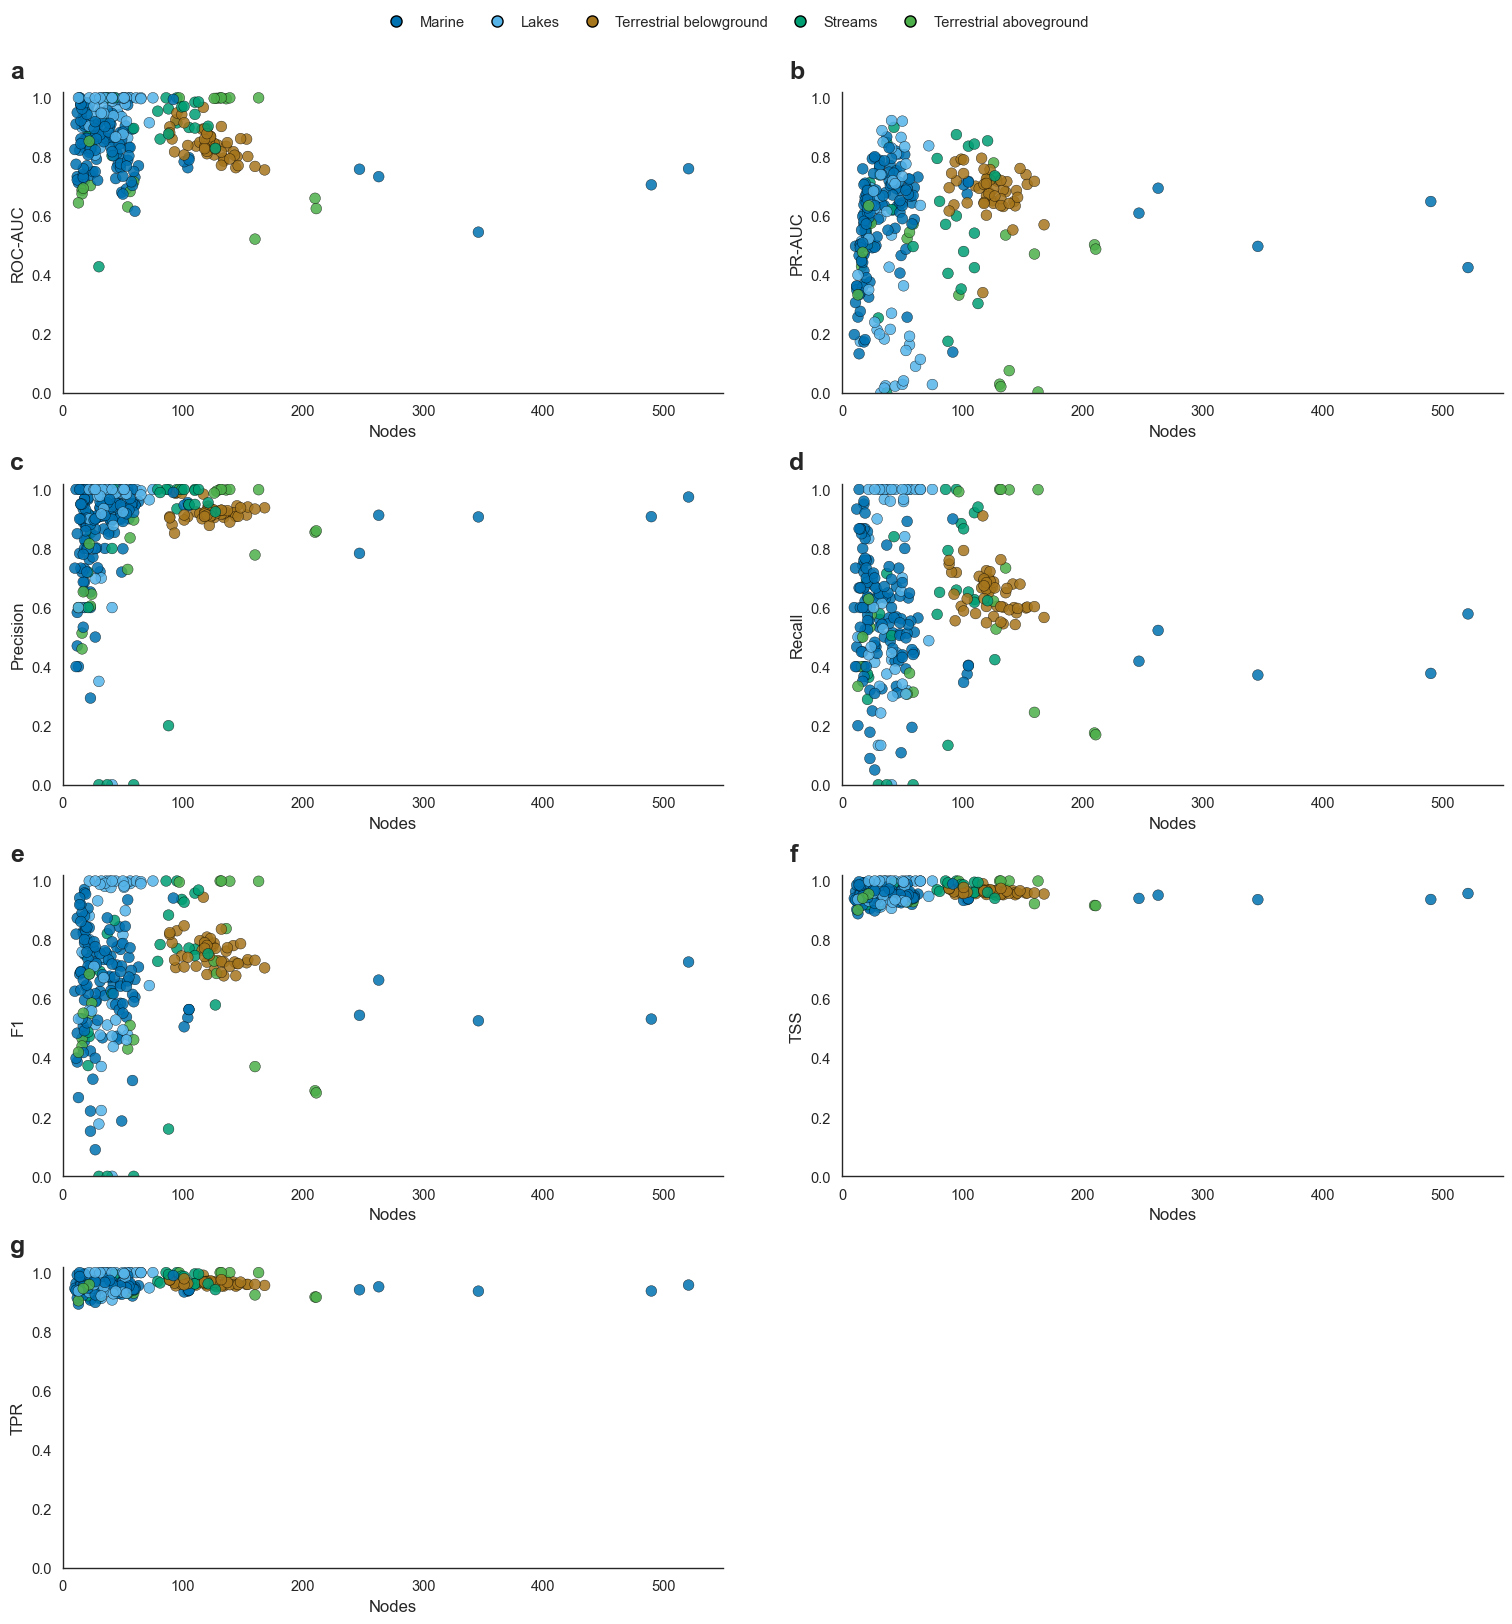

In [14]:
import glob
import math
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_FILE = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
MIN_NODES = 0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("F1Score", "F1"),
    ("PseudoTSS", "TSS"),
    ("PseudoTPR", "TPR"),
]

ecosystem_palette = {
    "Lakes": "#56B4E9",
    "Streams": "#009E73",
    "Marine": "#0072B2",
    "Terrestrial aboveground": "#4DAF4A",
    "Terrestrial belowground": "#A6761D",
}

Y_MIN, Y_MAX = 0, 1.0
Y_PAD_TOP = 0.02   # small padding so top points are not visually cut
X_MAX = 550
N_COLS = 2

# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()
    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
    }
    return label_map.get(name, str(name).strip().capitalize())

# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ECOSYSTEM_FILE)

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(df_ecosystem, ["ecosystemtype", "ecosystem", "ecosystem_type"])
nodes_col = find_column(df_ecosystem, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

df_ecosystem = df_ecosystem.rename(columns={
    foodweb_col: "Foodweb",
    ecosystem_col: "EcosystemType",
    nodes_col: "Nodes",
})

df_ecosystem["Foodweb"] = df_ecosystem["Foodweb"].astype(str)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

# ============================================================
# Load results
# ============================================================
csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))
if not csv_files:
    raise RuntimeError(f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = extract_foodweb_name(file)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Backward compatibility if some files still use AUC instead of ROC_AUC
if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"})

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]
if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

# ============================================================
# Merge + filter to TrainRatio = 60
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", "Nodes"]],
    on="Foodweb",
    how="left"
)

# ============================================================
# Filter to TrainRatio = 60 and Nodes >= 40
# ============================================================
if "TrainRatio" not in df_merged.columns:
    raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

df_merged["TrainRatio"] = pd.to_numeric(df_merged["TrainRatio"], errors="coerce")
df_merged["Nodes"] = pd.to_numeric(df_merged["Nodes"], errors="coerce")

before_rows = len(df_merged)
before_foodwebs = df_merged["Foodweb"].nunique()

df_tr = df_merged[
    (df_merged["TrainRatio"] == TARGET_RATIO) &
    (df_merged["Nodes"] >= MIN_NODES)
].copy()

after_rows = len(df_tr)
after_foodwebs = df_tr["Foodweb"].nunique()

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: {after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        f"No rows left after filtering TrainRatio = {TARGET_RATIO} "
        f"and Nodes >= {MIN_NODES}."
    )

# Mean per food web
agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}
df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
)

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

# ============================================================
# Ecosystem order + palette
# ============================================================
eco_order = df_scatter["EcosystemType"].value_counts().index.tolist()
df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows, N_COLS,
    figsize=(16, 4.5 * n_rows),
    sharex=False,
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    sns.scatterplot(
        data=df_scatter,
        x="Nodes",
        y=metric_col,
        hue="EcosystemType",
        palette=eco_palette,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3,
        s=60,
        legend=False,
        ax=ax,
    )

    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Nodes", fontsize=12)
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)

    ax.set_xlim(0, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    sns.despine(ax=ax)

    ax.text(
        -0.08, 1.03, panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

# Figure-level legend
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=8,
        markerfacecolor=eco_palette[name],
        markeredgecolor="black",
        label=format_ecosystem_label(name),
    )
    for name in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.6,
)

# fig.suptitle(f"Performance versus node count (TrainRatio = {int(TARGET_RATIO)}%)", y=0.995, fontsize=14)
fig.subplots_adjust(top=0.90, hspace=0.30, wspace=0.18, left=0.08, right=0.98, bottom=0.08)

plt.show()

Filtered data: TrainRatio = 90.0, Nodes >= 0. Rows kept: 1450 / 13050. Food webs kept: 290 / 290.


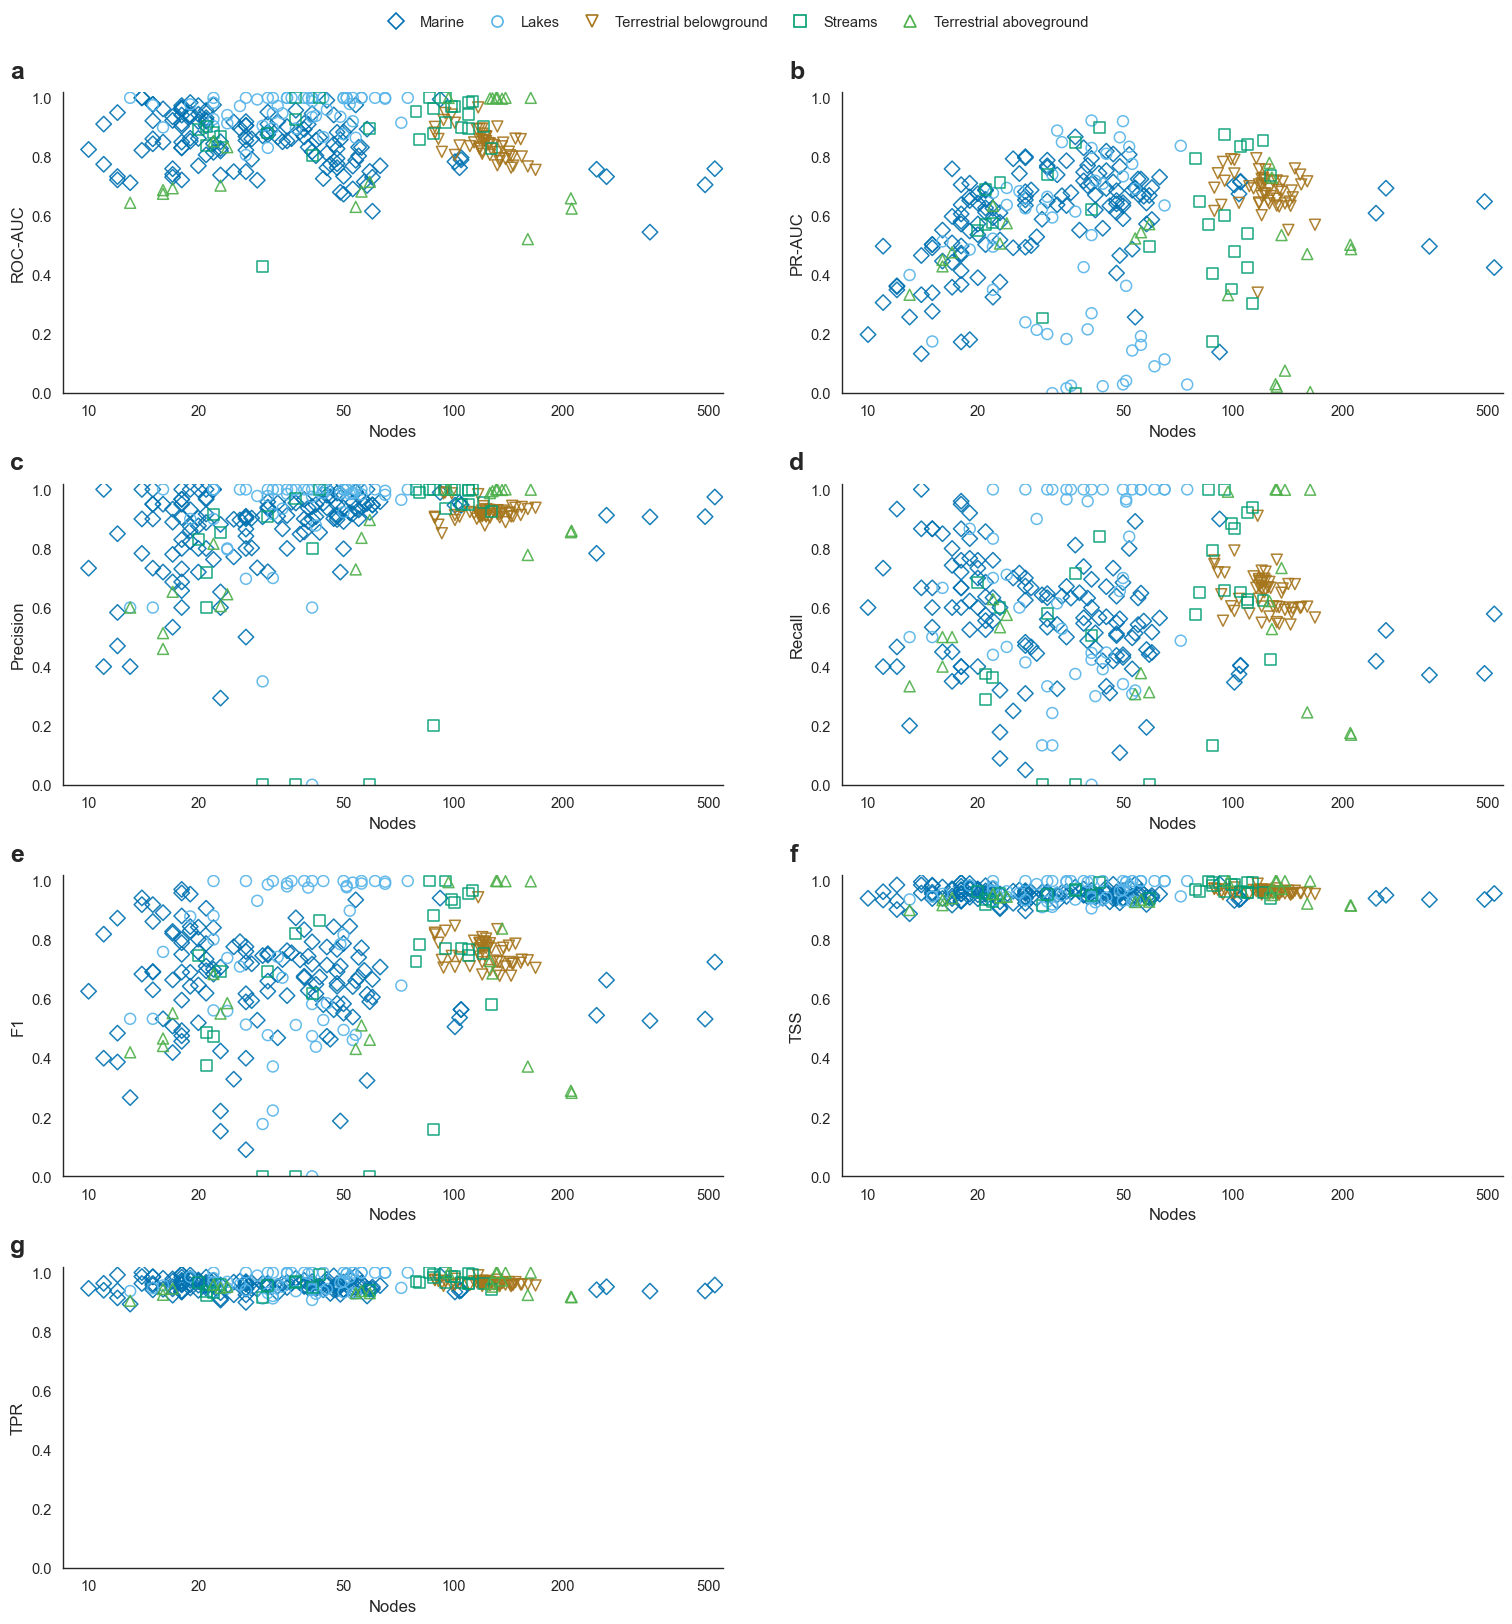

In [22]:
import glob
import math
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, ScalarFormatter, NullFormatter

sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_FILE = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
MIN_NODES = 0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("F1Score", "F1"),
    ("PseudoTSS", "TSS"),
    ("PseudoTPR", "TPR"),
]

ecosystem_palette = {
    "Lakes": "#56B4E9",
    "Streams": "#009E73",
    "Marine": "#0072B2",
    "Terrestrial aboveground": "#4DAF4A",
    "Terrestrial belowground": "#A6761D",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
}

Y_MIN, Y_MAX = 0, 1.0
Y_PAD_TOP = 0.02   # small padding so top points are not visually cut
X_MAX = 550
N_COLS = 2

# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()
    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
    }
    return label_map.get(name, str(name).strip().capitalize())

# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ECOSYSTEM_FILE)

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(df_ecosystem, ["ecosystemtype", "ecosystem", "ecosystem_type"])
nodes_col = find_column(df_ecosystem, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

df_ecosystem = df_ecosystem.rename(columns={
    foodweb_col: "Foodweb",
    ecosystem_col: "EcosystemType",
    nodes_col: "Nodes",
})

df_ecosystem["Foodweb"] = df_ecosystem["Foodweb"].astype(str)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

# ============================================================
# Load results
# ============================================================
csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))
if not csv_files:
    raise RuntimeError(f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = extract_foodweb_name(file)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Backward compatibility if some files still use AUC instead of ROC_AUC
if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"})

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]
if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

# ============================================================
# Merge + filter to TrainRatio = 60
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", "Nodes"]],
    on="Foodweb",
    how="left"
)

# ============================================================
# Filter to TrainRatio = 60 and Nodes >= 40
# ============================================================
if "TrainRatio" not in df_merged.columns:
    raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

df_merged["TrainRatio"] = pd.to_numeric(df_merged["TrainRatio"], errors="coerce")
df_merged["Nodes"] = pd.to_numeric(df_merged["Nodes"], errors="coerce")

before_rows = len(df_merged)
before_foodwebs = df_merged["Foodweb"].nunique()

df_tr = df_merged[
    (df_merged["TrainRatio"] == TARGET_RATIO) &
    (df_merged["Nodes"] >= MIN_NODES)
].copy()

after_rows = len(df_tr)
after_foodwebs = df_tr["Foodweb"].nunique()

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: {after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        f"No rows left after filtering TrainRatio = {TARGET_RATIO} "
        f"and Nodes >= {MIN_NODES}."
    )

# Mean per food web
agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}
df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
)

# Required for log-scaled x-axis.
df_scatter = df_scatter[df_scatter["Nodes"] > 0].copy()

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

x_min_log = max(1, df_scatter["Nodes"].min() * 0.85)

# ============================================================
# Ecosystem order + palette
# ============================================================
eco_order = df_scatter["EcosystemType"].value_counts().index.tolist()
df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

eco_markers = {
    eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
    for eco in eco_order
}

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows, N_COLS,
    figsize=(16, 4.5 * n_rows),
    sharex=False,
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    for eco in eco_order:
        sub = df_scatter[df_scatter["EcosystemType"] == eco]

        ax.scatter(
            sub["Nodes"],
            sub[metric_col],
            marker=eco_markers[eco],
            facecolors="none",
            edgecolors=eco_palette[eco],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(eco),
        )

    ax.set_xscale("log")
    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Nodes", fontsize=12)
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)

    ax.set_xlim(x_min_log, X_MAX)
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    sns.despine(ax=ax)

    ax.text(
        -0.08, 1.03, panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

# Figure-level legend
legend_handles = [
    Line2D(
        [0], [0],
        marker=eco_markers[name],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[name],
        markeredgewidth=1.2,
        label=format_ecosystem_label(name),
    )
    for name in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.6,
)

# fig.suptitle(f"Performance versus node count (TrainRatio = {int(TARGET_RATIO)}%)", y=0.995, fontsize=14)
fig.subplots_adjust(top=0.90, hspace=0.30, wspace=0.18, left=0.08, right=0.98, bottom=0.08)

plt.show()


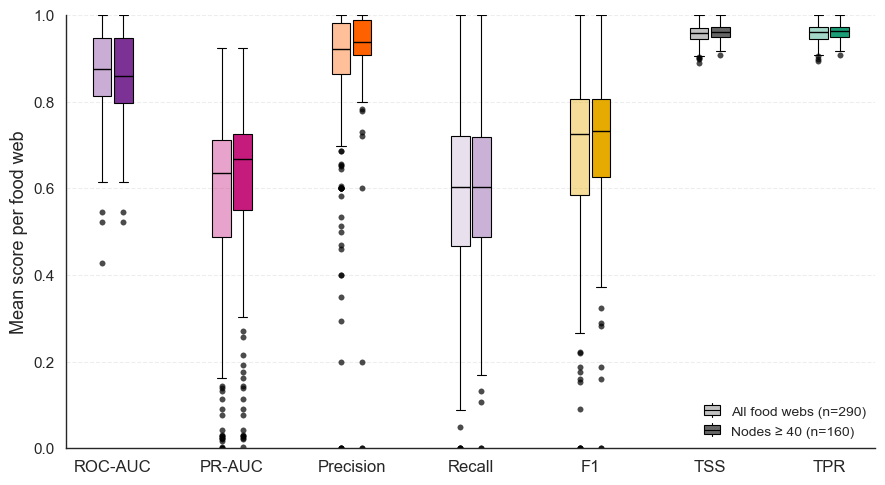

In [16]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# ============================================================
# Style
# ============================================================
sns.set_theme(style="white", context="paper", font_scale=1.2)


# ============================================================
# Week-15 palettes
# ============================================================
metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}


# ============================================================
# Config
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_FILE = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
NODES_THRESHOLD = 40

PLOT_METRICS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("F1Score", "F1"),
    ("PseudoTSS", "TSS"),
    ("PseudoTPR", "TPR"),
]

GROUP_ORDER = ["All food webs", f"Nodes ≥ {NODES_THRESHOLD}"]

# Same metric color, different opacity for the comparison
group_alpha = {
    "All food webs": 0.40,
    f"Nodes ≥ {NODES_THRESHOLD}": 1,
}


# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# Load metadata
# ============================================================
df_ecosystem = pd.read_csv(ECOSYSTEM_FILE)

foodweb_col = find_column(df_ecosystem, ["foodweb"])
nodes_col = find_column(df_ecosystem, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

df_ecosystem = df_ecosystem.rename(columns={
    foodweb_col: "Foodweb",
    nodes_col: "Nodes",
})

df_ecosystem["Foodweb"] = df_ecosystem["Foodweb"].astype(str)
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")


# ============================================================
# Load results
# ============================================================
csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))
if not csv_files:
    raise RuntimeError(f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = extract_foodweb_name(file)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Backward compatibility if the file still uses AUC instead of ROC_AUC
if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"})


# ============================================================
# Merge + filter
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "Nodes"]],
    on="Foodweb",
    how="left"
)

df_tr = df_merged[pd.to_numeric(df_merged["TrainRatio"], errors="coerce") == TARGET_RATIO].copy()
if df_tr.empty:
    raise RuntimeError(f"No rows for TrainRatio = {TARGET_RATIO}. Check TrainRatio values.")

required_metric_cols = [col for col, _ in PLOT_METRICS if col in df_tr.columns]
if not required_metric_cols:
    raise RuntimeError("None of the requested metrics were found in the results files.")

# Keep only metrics that actually exist
PLOT_METRICS = [(col, label) for col, label in PLOT_METRICS if col in df_tr.columns]


# ============================================================
# Mean per food web
# ============================================================
agg_dict = {metric_col: "mean" for metric_col, _ in PLOT_METRICS}

df_web = (
    df_tr
    .groupby(["Foodweb", "Nodes"], as_index=False)
    .agg(agg_dict)
)

# Comparison groups:
# 1) all food webs
# 2) same results after excluding <= 40 nodes
df_all_group = df_web.copy()
df_all_group["FilterGroup"] = "All food webs"

df_ge40_group = df_web[df_web["Nodes"] >= NODES_THRESHOLD].copy()
df_ge40_group["FilterGroup"] = f"Nodes ≥ {NODES_THRESHOLD}"

df_compare = pd.concat([df_all_group, df_ge40_group], ignore_index=True)
if df_compare.empty:
    raise RuntimeError("No data left after building the comparison groups.")


# ============================================================
# Long format
# ============================================================
df_long = pd.concat(
    [
        df_compare[["Foodweb", "FilterGroup", metric_col]]
        .rename(columns={metric_col: "Value"})
        .assign(Metric=metric_label)
        for metric_col, metric_label in PLOT_METRICS
    ],
    ignore_index=True,
)

df_long = df_long.dropna(subset=["Value"]).copy()
if df_long.empty:
    raise RuntimeError("No data left to plot after dropping missing metric values.")


# ============================================================
# Legend labels
# ============================================================
group_counts = df_compare.groupby("FilterGroup")["Foodweb"].nunique().to_dict()

group_display_labels = {
    g: f"{g} (n={group_counts.get(g, 0)})"
    for g in GROUP_ORDER
}


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(9.0, 5.0))

group_centers = 1.0 + np.arange(len(PLOT_METRICS)) * 1.8
offsets = np.array([-0.16, 0.16])
box_width = 0.28

for j, group_name in enumerate(GROUP_ORDER):
    data_for_group = []
    positions_for_group = []
    metric_labels_for_boxes = []

    for i, (_, metric_label) in enumerate(PLOT_METRICS):
        vals = (
            df_long.loc[
                (df_long["FilterGroup"] == group_name) &
                (df_long["Metric"] == metric_label),
                "Value"
            ]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_group.append(vals)
        positions_for_group.append(group_centers[i] + offsets[j])
        metric_labels_for_boxes.append(metric_label)

    bp = ax.boxplot(
        data_for_group,
        positions=positions_for_group,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            edgecolor="black",
            linewidth=0.8,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

    for box, metric_label in zip(bp["boxes"], metric_labels_for_boxes):
        box.set_facecolor(to_rgba(metric_palette[metric_label], alpha=group_alpha[group_name]))

legend_handles = [
    {
        "facecolor": to_rgba("#666666", alpha=group_alpha[g]),
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for g in GROUP_ORDER
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [metric_label for _, metric_label in PLOT_METRICS],
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Mean score per food web", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
sns.despine(ax=ax)

ax.legend(
    handles=legend_handles,
    labels=[group_display_labels[g] for g in GROUP_ORDER],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 290


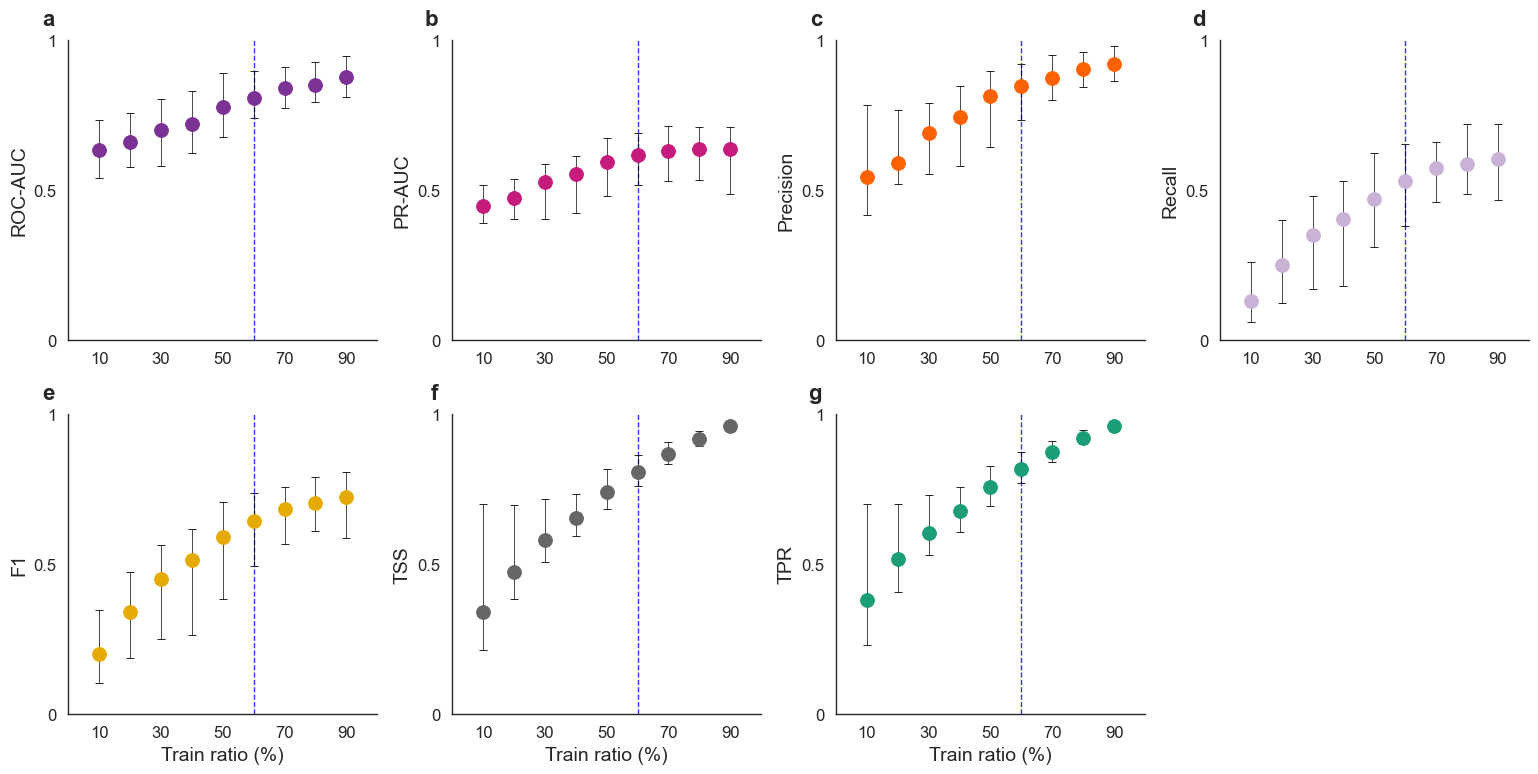

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None
METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = False
Y_MIN = 0.0

# Static y-axis for all panels
INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_tax_mass_results_random_wlnm_dir_neg", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    # Keep all plotted train-ratio values, but only label the main x-axis ticks.
    visible_ticks = [10, 30, 50, 70, 90]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels([str(t) for t in visible_ticks])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}
# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False
)

# Make axes always 2D, then flatten for easy indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    # No panel title; use the metric name as the y-axis title for each panel
    ax.set_title("")

    row_idx = i // n_cols
    col_idx = i % n_cols

    # x-label only on bottom row
    if row_idx == n_rows - 1:
        ax.set_xlabel("Train ratio (%)", fontsize=14)
    else:
        ax.set_xlabel("")

    # y-axis title for each panel
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=14)

    # Panel letters
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=16,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=12)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

# Hide any unused subplot(s)
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Foodwebs with Nodes > 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Matched foodweb keys: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Metrics found: ['ROC_AUC', 'PR_AUC', 'Precision', 'Recall', 'F1Score', 'PseudoTSS', 'PseudoTPR']
[INFO] Total food webs plotted: 288
[INFO] Train ratios detected: [10, 20, 30, 40, 50, 60, 70, 80, 90]


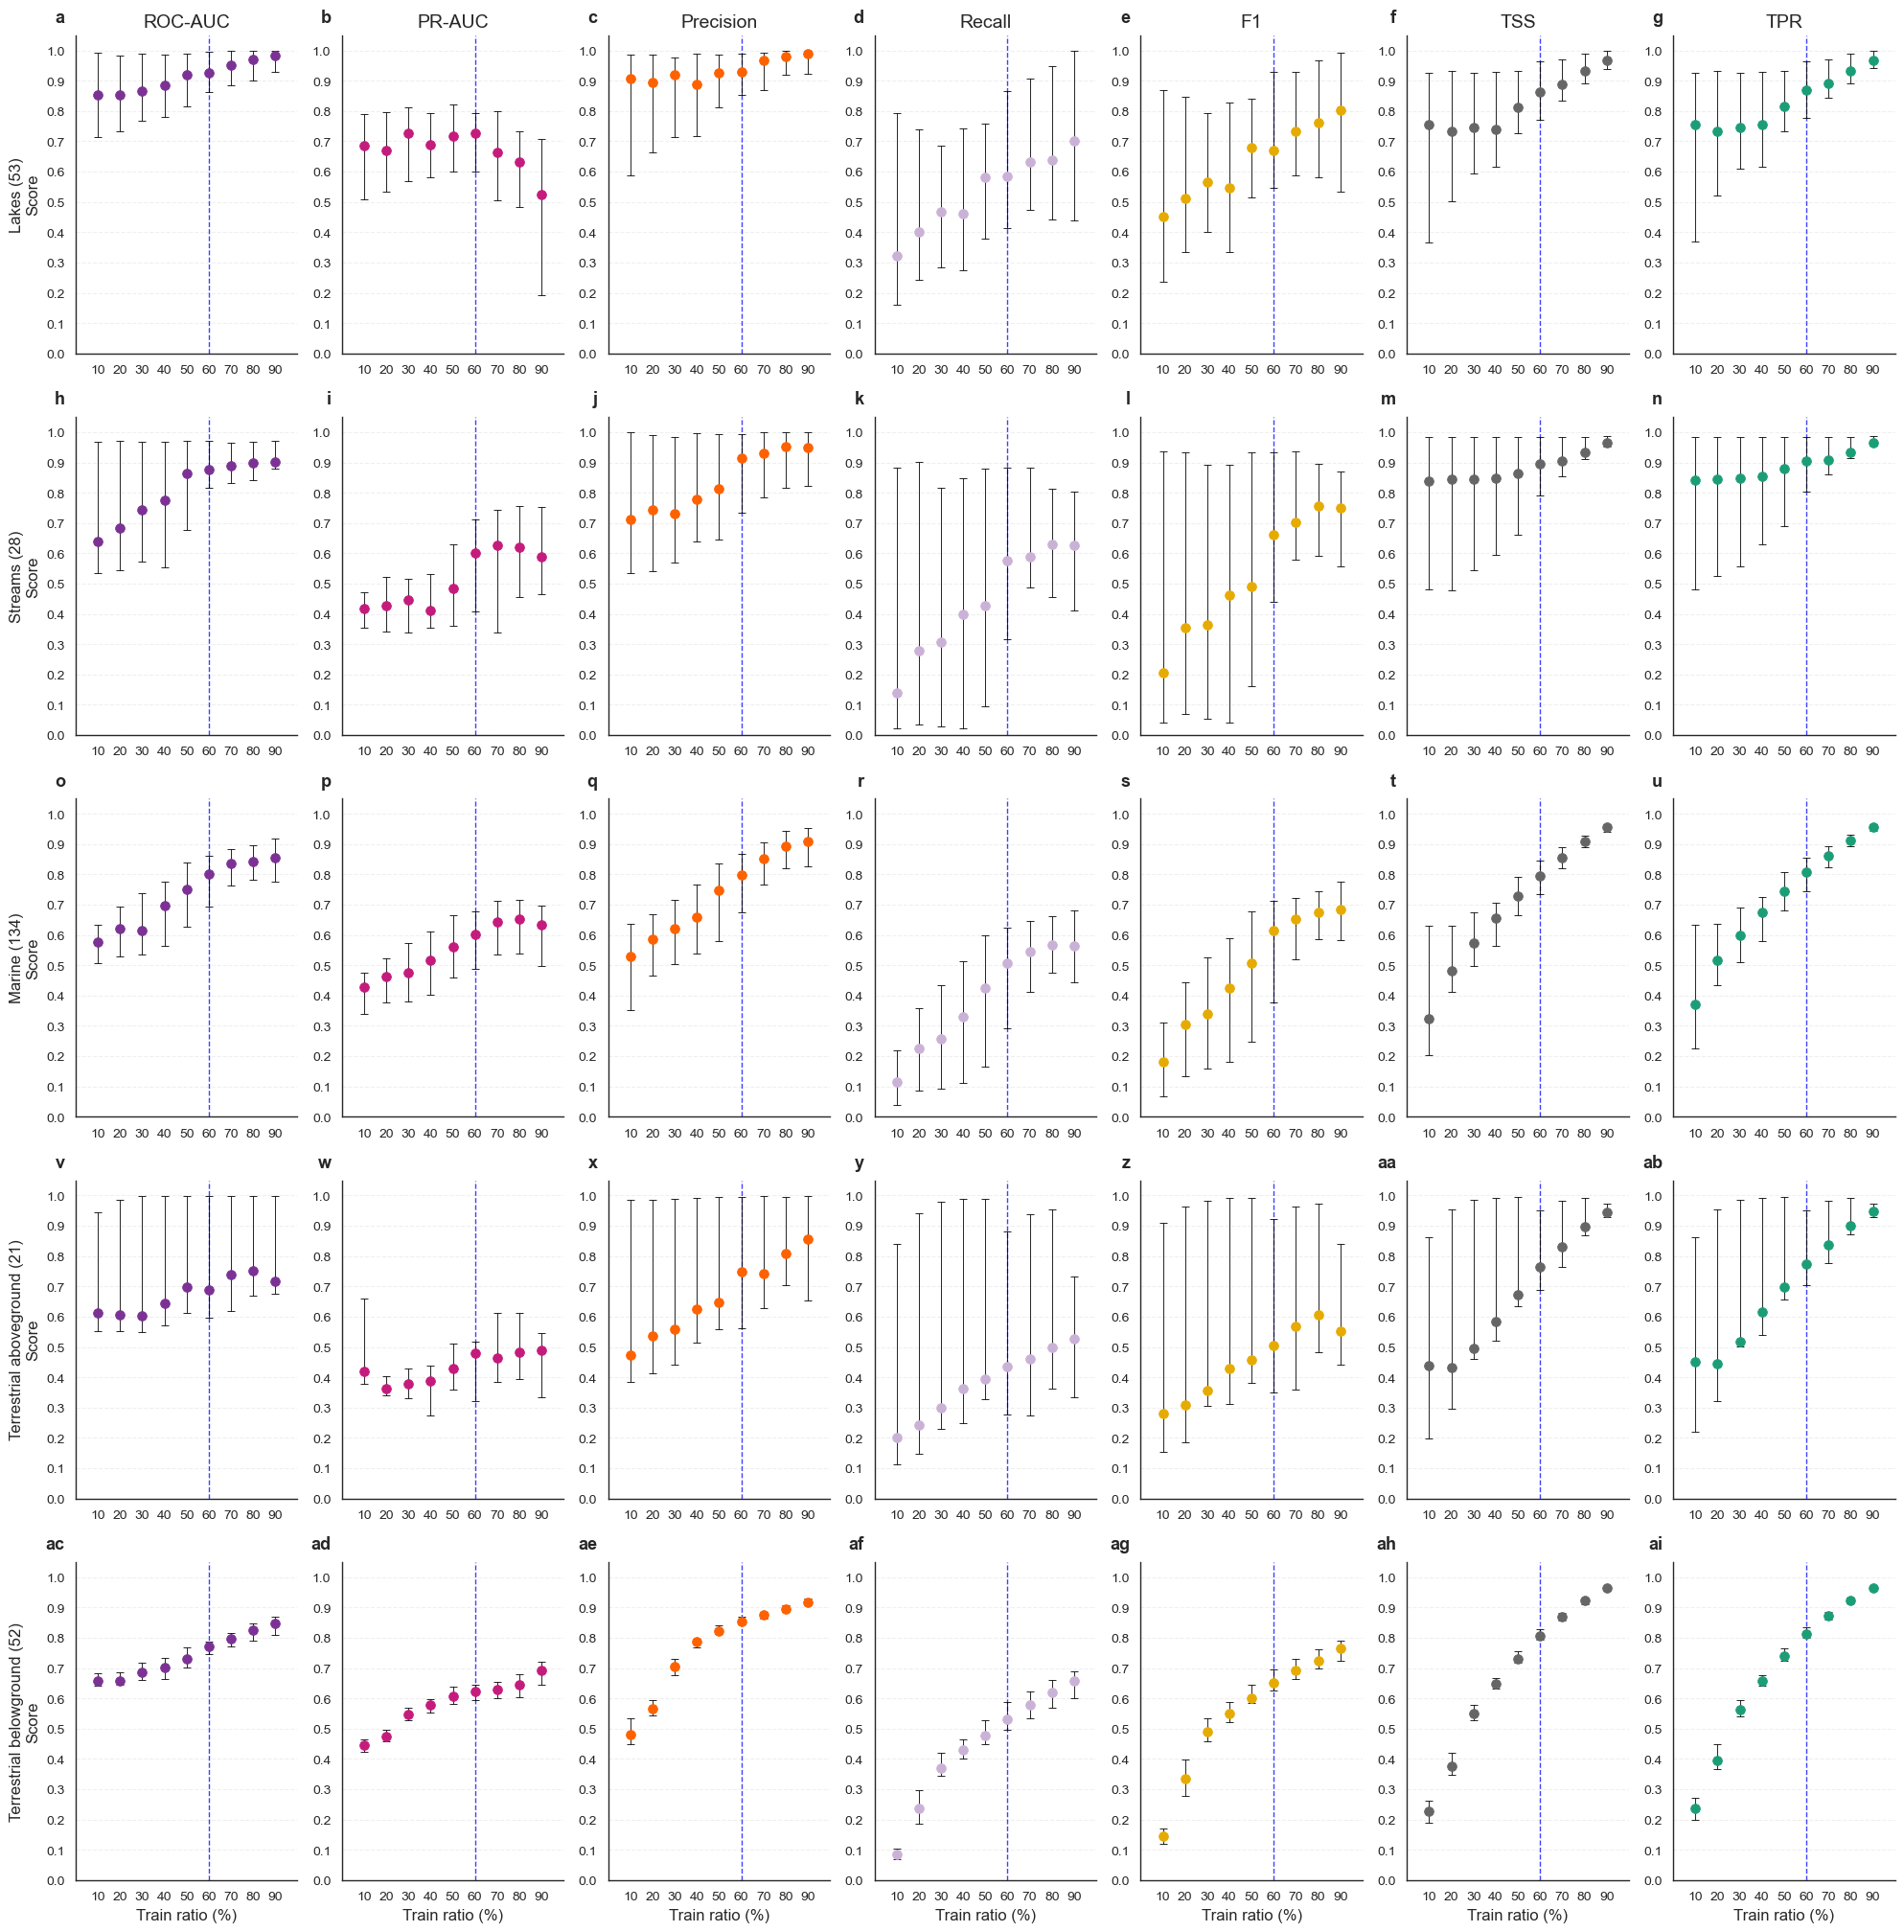

In [19]:
import os
import re
import glob
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None

METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = True

# Fixed y-axis scale for all panels
Y_MIN = 0
Y_MAX = 1.05          # visual headroom so points near 1.0 are not cut
Y_TICK_MAX = 1.0      # labelled ticks stop at 1.0

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name = os.path.basename(name)
    name, _ = os.path.splitext(name)

    name = name.lower()
    name = re.sub(r"[\s\-]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")

    suffixes = [
        "_results_random_wlnm_dir_neg",
        "_result_random_wlnm_dir_neg",
        "_results_wlnm_dir_neg",
        "_result_wlnm_dir_neg",
        "_random_wlnm_dir_neg",
        "_wlnm_dir_neg",
        "_results_random",
        "_result_random",
        "_results",
        "_result",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]

    changed = True
    while changed:
        changed = False
        for suffix in suffixes:
            if name.endswith(suffix):
                name = name[: -len(suffix)]
                changed = True

    name = re.sub(r"_+", "_", name).strip("_")
    return name


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []

    for path in paths:
        try:
            tmp = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        tmp.columns = [c.strip() for c in tmp.columns]
        tmp = tmp.rename(columns={c: c.upper() for c in tmp.columns})

        if "FOODWEB" not in tmp.columns:
            tmp["FOODWEB"] = derive_foodweb_from_filename(path)

        tmp["SOURCE_FILE"] = os.path.basename(path)
        frames.append(tmp)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [
        c for c in columns
        if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]
    ]

    if not candidates:
        print("[DEBUG] Available columns:")
        print(list(columns))
        raise ValueError("No TrainRatio column found.")

    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    ax.set_xticks(train_ratios)
    ax.set_xticklabels([str(int(t)) if int(t) % 10 == 0 else "" for t in train_ratios])


def panel_label(index: int) -> str:
    letters = string.ascii_lowercase
    label = ""

    index += 1
    while index > 0:
        index, remainder = divmod(index - 1, 26)
        label = letters[remainder] + label

    return label


# =========================
# Load results
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

# =========================
# Load metadata
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    print("[DEBUG] Metadata columns:")
    print(meta.columns.tolist())
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

# =========================
# Normalise matching keys
# =========================
meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta[nodes_col] = pd.to_numeric(meta[nodes_col], errors="coerce")

meta_filtered = meta.loc[
    meta[nodes_col] > NODES_THRESHOLD,
    ["FW_KEY", ecosystem_col]
].copy()

meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = (
    meta_filtered["ECOSYSTEM"]
    .astype(str)
    .str.strip()
    .str.lower()
)

meta_filtered = meta_filtered.drop_duplicates(subset=["FW_KEY"])

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

result_keys = set(df["FW_KEY"].unique())
meta_keys = set(meta_filtered["FW_KEY"].unique())
matched_keys = result_keys.intersection(meta_keys)

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD}: {len(meta_keys)}")
print(f"[INFO] Foodwebs in results before filter: {len(result_keys)}")
print(f"[INFO] Matched foodweb keys: {len(matched_keys)}")

if len(matched_keys) == 0:
    print("\n[DEBUG] Example result FW_KEY values:")
    print(sorted(list(result_keys))[:20])

    print("\n[DEBUG] Example metadata FW_KEY values:")
    print(sorted(list(meta_keys))[:20])

    raise ValueError(
        "No matching food-web keys between result CSVs and metadata. "
        "Check filename normalization and FOODWEB_CSV labels."
    )

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)

df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].round().astype(int)

# =========================
# Metrics
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]

if not metrics_present:
    print("[DEBUG] Available result columns:")
    print(df.columns.tolist())
    raise ValueError(
        "None of the requested metrics were found. "
        "Check METRICS against the CSV column names."
    )

print(f"[INFO] Metrics found: {metrics_present}")

# =========================
# Long format
# =========================
df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long = df_long.dropna(subset=["Value"]).copy()

df_web_means = (
    df_long
    .groupby(["FOODWEB", "ECOSYSTEM", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

if df_web_means.empty:
    raise ValueError("No valid metric values left after converting metrics to numeric.")

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["ECOSYSTEM", "TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Total food webs plotted: {n_webs}")
print(f"[INFO] Train ratios detected: {train_ratios}")

# =========================
# Ecosystem order
# =========================
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = summary["ECOSYSTEM"].dropna().unique().tolist()

ecosystem_order = [e for e in preferred_ecosystem_order if e in ecosystems_present]
ecosystem_order += [e for e in ecosystems_present if e not in ecosystem_order]

if not ecosystem_order:
    raise ValueError("No ecosystems found after filtering and merging metadata.")

# =========================
# Colours and labels
# =========================
metric_colors = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "PseudoTSS": "#666666",
    "PseudoTPR": "#1B9E77",
}

ecosystem_display_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

# =========================
# Final plot: ecosystems x metrics
# Rows = ecosystems, Columns = metrics
# =========================
n_rows = len(ecosystem_order)
n_cols = len(metrics_present)

fig_width = max(10, 3.5 * n_cols)
fig_height = max(25, 4 * n_rows)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=False,
    sharey=False
)

if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

letter_idx = 0

for r, ecosystem in enumerate(ecosystem_order):
    for c, metric in enumerate(metrics_present):
        ax = axes[r, c]

        sub = summary[
            (summary["ECOSYSTEM"] == ecosystem) &
            (summary["Metric"] == metric)
        ].sort_values("TRAINRATIO")

        if sub.empty:
            ax.set_axis_off()
            continue

        x = sub["TRAINRATIO"].to_numpy()
        y = sub["median"].to_numpy()

        yerr = np.vstack([
            (sub["median"] - sub["q25"]).to_numpy(),
            (sub["q75"] - sub["median"]).to_numpy(),
        ])

        color = metric_colors.get(metric, "black")

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o",
            linestyle="none",
            color=color,
            ecolor="black",
            markersize=7,
            linewidth=1.2,
            elinewidth=0.6,
            capsize=3,
            capthick=0.8,
            markerfacecolor=color,
            markeredgecolor=color,
            markeredgewidth=0.6,
            zorder=3,
        )

        ax.axvline(
            x=60,
            color="blue",
            linestyle="--",
            linewidth=1.0,
            alpha=0.75,
            zorder=1,
        )

        # Same fixed y-axis scale in every panel
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.set_yticks(np.arange(Y_MIN, Y_TICK_MAX + 0.01, 0.1))
        ax.tick_params(axis="y", which="both", labelleft=True)
        plt.setp(ax.get_yticklabels(), visible=True)

        # Same fixed x-axis scale in every panel
        ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)
        set_trainratio_ticks(ax, train_ratios)
        ax.tick_params(axis="x", which="both", labelbottom=True)

        if SHOW_GRID:
            ax.grid(True, axis="y", linestyle="--", alpha=0.30)
        else:
            ax.grid(False)

        sns.despine(ax=ax)

        if r == 0:
            ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=14)

        if c == 0:
            n_ecosystem_webs = df_web_means.loc[
                df_web_means["ECOSYSTEM"] == ecosystem,
                "FOODWEB"
            ].nunique()

            display_ecosystem = ecosystem_display_labels.get(ecosystem, ecosystem)

            ax.set_ylabel(
                f"{display_ecosystem} ({n_ecosystem_webs})\nScore",
                fontsize=12
            )
        else:
            ax.set_ylabel("")

        if r == n_rows - 1:
            ax.set_xlabel("Train ratio (%)", fontsize=12)

        ax.annotate(
            panel_label(letter_idx),
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-8, 7),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=13,
            fontweight="bold",
            annotation_clip=False,
        )

        letter_idx += 1

        ax.tick_params(axis="both", labelsize=10)

plt.show()

Found 290 CSV files matching pattern in ../../../src/matlab/data/result_kfold_cross-validation_pseudo_properties/prediction_scores_logs

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64


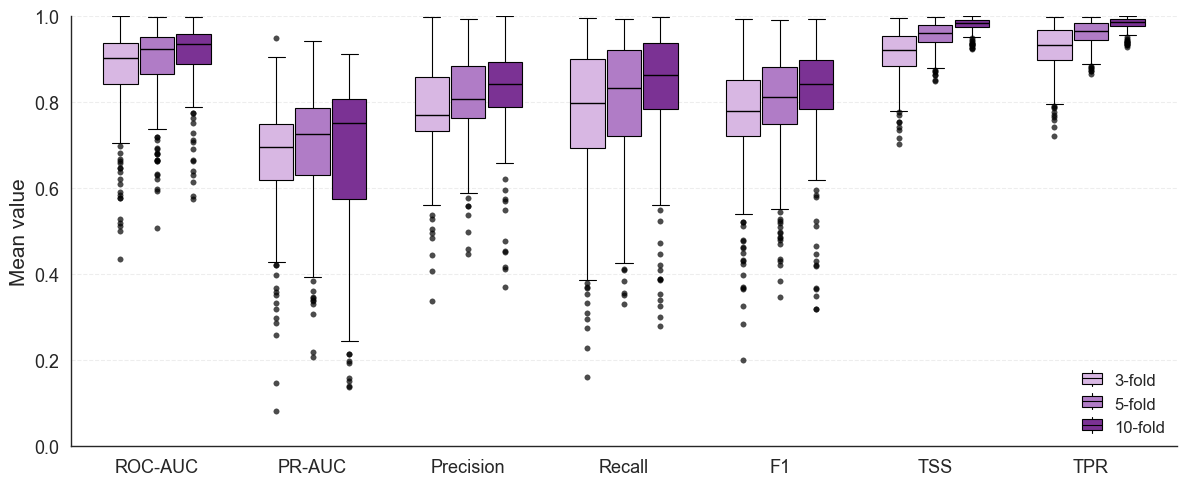

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

# =========================
# Style (match old snippet)
# =========================
sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR = "../../../src/matlab/data/result_kfold_cross-validation_pseudo_properties/prediction_scores_logs"
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]
METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]

# -----------------------------
# Helpers
# -----------------------------
def cvk_label(k: int) -> str:
    return f"{k}-fold"

def foodweb_name_from_path(p: str) -> str:
    return os.path.basename(p).replace("_tax_mass_results_random_wlnm_dir_neg_kfold.csv", "")

def collect_foodweb_means(log_dir: str, pattern: str) -> pd.DataFrame:
    required_cols = {"CvK", *METRICS}

    rows = []
    csv_files = sorted(glob.glob(os.path.join(log_dir, pattern)))
    print(f"Found {len(csv_files)} CSV files matching pattern in {log_dir}")

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {os.path.basename(csv_path)} read error: {e}")
            continue

        missing = required_cols - set(df.columns)
        if missing:
            print(f"[SKIP] {os.path.basename(csv_path)} missing columns: {sorted(missing)}")
            continue

        # Filter by K if present
        if "K" in df.columns:
            df = df[df["K"] == K_TARGET].copy()

        # Keep only desired CV regimes
        df = df[df["CvK"].isin(cvk_order)].copy()
        if df.empty:
            print(f"[SKIP] {os.path.basename(csv_path)} no rows after K/CvK filtering.")
            continue

        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce").astype("Int64")

        # Mean across ALL fold-level rows for each CvK (per food web)
        agg = (
            df.groupby("CvK", as_index=False)[METRICS]
              .mean()
        )

        fw = foodweb_name_from_path(csv_path)
        agg["Foodweb"] = fw

        rows.append(agg)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_foodweb_means_1x4(df_means: pd.DataFrame) -> None:
    if df_means.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if k in df_means["CvK"].dropna().unique()]
    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    plot_metrics = [
        ("ROC_AUC", "ROC-AUC"),
        ("PR_AUC", "PR-AUC"),
        ("Precision", "Precision"),
        ("Recall", "Recall"),
        ("F1Score", "F1"),
        ("PseudoTSS", "TSS"),
        ("PseudoTPR", "TPR"),
    ]

    cvk_palette = {
        3: "#D8B7E3",    # light purple
        5: "#B07CC6",    # medium purple
        10: "#7B3294",   # dark ROC-AUC purple
    }

    label_map = {
        3: "3-fold",
        5: "5-fold",
        10: "10-fold",
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.array([-0.34, 0.0, 0.34])
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []
        metrics_for_boxes = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = (
                df_means.loc[df_means["CvK"] == cvk, metric]
                .dropna()
                .values
            )

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])
            metrics_for_boxes.append(metric)

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(
                edgecolor="black",
                linewidth=0.8,
            ),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box, metric in zip(bp["boxes"], metrics_for_boxes):
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([label for _, label in plot_metrics], ha="center", fontsize=13)

    ax.set_ylabel("Mean value", fontsize=15)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower right",
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Run
# -----------------------------
df_means = collect_foodweb_means(LOG_DIR, PATTERN)

print("\nFoodweb count per CvK:")
print(df_means.groupby("CvK")["Foodweb"].nunique())

plot_foodweb_means_1x4(df_means)